##### Import package và đọc dữ liệu

**Import thư viện** — `numpy`, `pandas` để xử lý dữ liệu dạng bảng; `matplotlib` & `seaborn` để trực quan hóa. `warnings.filterwarnings('ignore')` ẩn các cảnh báo để output gọn gàng.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

**Đọc dữ liệu gốc** từ file Excel (`header=0`: dòng đầu tiên là tên cột). `drop_duplicates()` loại bỏ các dòng bị trùng hoàn toàn, sau đó hiển thị DataFrame để xem tổng quan.

In [4]:
df = pd.read_excel('data\\raw\\SoLieuCPDieuTri2016.xlsx', header = 0)
df = df.drop_duplicates()
df

,ID,NAMSINH,Unnamed: 2,DANTOC,TENPXA,TENQUANHUYEN,TENTINHTHANH,MAICD,CHANDOAN,NGAYVAO,NGAYRA,TONGCP,BHYT_TT,thờ gian điều trị,Unnamed: 14,Unnamed: 15,Unnamed: 16
0,160101000007636000,1988,NaN,Kinh,Phường Nhơn Bình,Thành phố Qui Nhơn,Bình Định,S01.1;,Vết thương hở của mi mắt và vùng quanh mắt;,2016-01-01 00:55:00,2016-01-01 01:04:00,1.500000e+04,0.000000e+00,0.006250,0,NaN,0.0
1,160101000007640000,1998,NaN,Kinh,Phường Nhơn Phú,Thành phố Qui Nhơn,Bình Định,I20;,Cơn đau thắt ngực;,2016-01-01 01:37:00,2016-01-01 03:23:00,8.334650e+04,8.334650e+04,0.073611,0,NaN,NaN
2,160101000007640992,1980,NaN,Kinh,Xã Nhơn Lộc,Thị xã An Nhơn,Bình Định,J68.2;P71.0;,Viêm hô hấp trên;Hạ calci máu;,2016-01-01 03:31:00,2016-01-01 05:00:00,1.599990e+02,0.000000e+00,0.061806,0,NaN,NaN
3,160104000001348000,2010,NaN,Kinh,Phường Trần Quang Diệu,Thành phố Qui Nhơn,Bình Định,A91.A;,Sốt xuất huyết Dengue;,2015-12-29 20:25:00,2016-01-01 07:00:00,1.129380e+05,1.129380e+05,2.440972,2,NaN,NaN
4,160105000001870016,2010,NaN,Kinh,Phường Nhơn Phú,Thành phố Qui Nhơn,Bình Định,A91;J00;,Sốt xuất huyết Dengue;Viêm Họng Cấp;,2015-12-25 08:44:00,2016-01-01 07:00:00,2.623950e+05,2.623950e+05,6.927778,7,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68757,161231000008860000,1943,NaN,Kinh,Phường Trần Quang Diệu,Thành phố Qui Nhơn,Bình Định,Y84.1;D63.0;,Chạy thận nhân tạo;Thiếu máu trong bệnh suy th...,2016-12-01 08:11:00,2016-12-31 23:00:00,1.102239e+07,1.102239e+07,30.617361,31,NaN,NaN
68758,161231000008870016,1992,NaN,La chí,Phường Bình Định,Thị xã An Nhơn,Bình Định,Y84.1;,Chạy thận nhân tạo;,2016-11-19 06:53:00,2016-12-31 23:00:00,1.359227e+07,1.359227e+07,42.671528,43,NaN,NaN
68759,161231000008868000,1974,NaN,Kinh,Xã Nhơn Phúc,Thị xã An Nhơn,Bình Định,Y84.1;,Chạy thận nhân tạo;,2016-11-19 06:52:00,2016-12-31 23:00:00,1.021012e+07,1.021012e+07,42.672222,43,NaN,NaN
68760,161231000000881984,1976,NaN,Kinh,Xã Mỹ Thọ,Huyện Phù Mỹ,Bình Định,Y84.1;J18;,Chạy thận nhân tạo;Viêm phổi;,2016-11-10 06:56:00,2016-12-31 23:00:00,1.734061e+07,1.734061e+07,51.669444,52,NaN,NaN


**Kiểm tra cấu trúc dữ liệu** bằng `info()`: số dòng, tên cột, kiểu dữ liệu và số giá trị non-null của từng cột — giúp phát hiện cột rỗng và kiểu dữ liệu cần chuyển đổi.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 68762 entries, 0 to 68761
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   ID                 68762 non-null  int64         
 1   NAMSINH            68762 non-null  int64         
 2   Unnamed: 2         0 non-null      float64       
 3   DANTOC             68762 non-null  str           
 4   TENPXA             68762 non-null  str           
 5   TENQUANHUYEN       68762 non-null  str           
 6   TENTINHTHANH       68762 non-null  str           
 7   MAICD              68762 non-null  str           
 8   CHANDOAN           68762 non-null  str           
 9   NGAYVAO            68762 non-null  datetime64[us]
 10  NGAYRA             68762 non-null  datetime64[us]
 11  TONGCP             68762 non-null  float64       
 12  BHYT_TT            68762 non-null  float64       
 13  thờ gian điều trị  68762 non-null  float64       
 14  Unnamed: 14      

**Thống kê mô tả** các cột số (`count, mean, std, min, max`, các phân vị). `.T` xoay bảng để mỗi cột nằm trên một dòng cho dễ đọc.

In [10]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
NAMSINH,68762.0,1976.338588,1909.0,1955.0,1979.0,1996.0,2016.0,26.136605
NGAYVAO,68762,2016-07-17 13:04:55.489660,2010-04-09 08:02:00,2016-05-12 14:15:30,2016-08-02 06:02:30,2016-10-16 19:22:45,2016-12-31 22:26:00,NaN
NGAYRA,68762,2016-07-25 01:03:18.162647,2016-01-01 01:04:00,2016-05-20 18:00:00,2016-08-09 16:00:00,2016-10-24 11:15:00,2016-12-31 23:47:00,NaN
TONGCP,68762.0,4417028.483334,1.7955,718131.99985,1844088.74975,4598382.234675,163899935.92775,8252480.071179
BHYT_TT,68762.0,1808397.222321,-353702.811,0.0,0.0,1242017.136375,204226603.9085,5871595.890781
Thời gian điều trị,68762.0,7.498874,-5.96875,2.284028,4.857639,8.279861,2142.290278,17.485679


**Loại bỏ cột không cần thiết**: `ID` và 4 cột rỗng/dư thừa (`Unnamed: 2, 14, 15, 16`). Đồng thời đổi tên cột `'thờ gian điều trị'` (gõ sai chính tả) thành `'Thời gian điều trị'`.

In [11]:
df = df.drop(columns = ['ID','Unnamed: 2','Unnamed: 14','Unnamed: 15','Unnamed: 16']) 
df = df.rename(columns = {'thờ gian điều trị': 'Thời gian điều trị'}) 

KeyError: "['ID', 'Unnamed: 2', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16'] not found in axis"

**Soát lỗi dữ liệu**: tìm các dòng có chi phí BHYT thanh toán (`BHYT_TT`) âm — giá trị vô lý do nhập sai.

In [ ]:
df[df['BHYT_TT'] < 0]

,NAMSINH,DANTOC,TENPXA,TENQUANHUYEN,TENTINHTHANH,MAICD,CHANDOAN,NGAYVAO,NGAYRA,TONGCP,BHYT_TT,Thời gian điều trị
22762,1968,Kinh,Xã Nhơn Lý,Thành phố Qui Nhơn,Bình Định,C22.1;,Carcinom đường mật trong gan;,2016-05-23 09:34:00,2016-06-20 08:00:00,4280612.3,-353702.811,27.934722


**Soát lỗi dữ liệu**: tìm các dòng có `Thời gian điều trị` âm (ngày ra trước ngày vào → bản ghi lỗi).

In [ ]:
df[df['Thời gian điều trị'] < 0]

,NAMSINH,DANTOC,TENPXA,TENQUANHUYEN,TENTINHTHANH,MAICD,CHANDOAN,NGAYVAO,NGAYRA,TONGCP,BHYT_TT,Thời gian điều trị
2773,1967,Kinh,Xã Mỹ Đức,Huyện Phù Mỹ,Bình Định,K29;,Loét xuất huyết dạ dày/ U gan di căn dạ dày;,2016-01-20 07:15:00,2016-01-14 08:00:00,2.204924e+06,0.000000e+00,-5.968750
16045,1976,Kinh,Xã Hoài Châu,Huyện Hoài Nhơn,Bình Định,J91;,Tràn dịch màng phổi trong bệnh phân loại nơi k...,2016-05-11 11:30:00,2016-05-11 08:00:00,1.602093e+06,0.000000e+00,-0.145833
16983,1998,Kinh,Phường Lê Hồng Phong,Thành phố Qui Nhơn,Bình Định,S92;,Vết thương bàn chân(P);,2016-05-19 17:01:00,2016-05-19 15:00:00,2.578825e+06,0.000000e+00,-0.084028
18100,1973,Kinh,Phường Trần Hưng Đạo,Thành phố Qui Nhơn,Bình Định,G93.2;,Tăng áp lực trong sọ lành tính;,2016-05-28 22:26:00,2016-05-28 17:00:00,1.190000e+05,1.190000e+05,-0.226389
20596,1986,Kinh,Phường Ngô Mây,Thành phố Qui Nhơn,Bình Định,X45;,Say rượu / hen phế quản;,2016-06-09 23:36:00,2016-06-09 18:00:00,2.730458e+05,2.730458e+05,-0.233333
20743,1926,Kinh,Xã Phước Hiệp,Huyện Tuy Phước,Bình Định,T01;S06;,Đa vết thương phần mền do bị chém;Tổn thương n...,2016-06-10 22:56:00,2016-06-10 15:00:00,9.979440e+05,9.979440e+05,-0.330556
21020,2008,Kinh,Xã Mỹ Phong,Huyện Phù Mỹ,Bình Định,S42;,PT lồi cầu xương cánh tay;,2016-06-12 18:12:00,2016-06-12 15:00:00,1.709073e+06,1.709073e+06,-0.133333
23686,1980,Kinh,Phường Quang Trung,Thành phố Qui Nhơn,Bình Định,S61;,Vết thương hở ở cổ tay và bàn tay;,2016-06-23 23:53:00,2016-06-23 16:00:00,1.319440e+05,0.000000e+00,-0.328472
24657,1980,Kinh,Xã Phước Thành,Huyện Tuy Phước,Bình Định,K56;,"Liệt Ruột,tắc Ruột;",2016-06-28 00:53:00,2016-06-27 23:00:00,3.463700e+04,0.000000e+00,-0.078472
28131,1981,Kinh,Phường Nhơn Phú,Thành phố Qui Nhơn,Bình Định,S52;,Gẫy xương ở cẳng tay;,2016-07-13 20:11:00,2016-07-13 15:00:00,2.388880e+05,0.000000e+00,-0.215972


**Làm sạch dữ liệu**: chỉ giữ lại các dòng có `BHYT_TT >= 0` **và** `Thời gian điều trị >= 0`, loại bỏ các bản ghi lỗi đã phát hiện ở hai bước trên.

In [ ]:
df = df[(df['BHYT_TT'] >= 0) & (df['Thời gian điều trị'] >= 0)]

**Tạo đặc trưng Tuổi**: thay năm sinh bằng tuổi tại thời điểm nhập viện = `năm của NGAYVAO − NAMSINH`, rồi đổi tên cột `NAMSINH` thành `'Tuổi'`.

In [ ]:
df['NAMSINH'] = list(map(lambda x,y: y - x,df['NAMSINH'],df['NGAYVAO'].dt.year)) # Chuyển cột NAMSINH thành cột Tuổi
df = df.rename(columns = {'NAMSINH': 'Tuổi'})

**Chuẩn hóa dữ liệu**: viết HOA toàn bộ tên Phường/Xã, Quận/Huyện, Tỉnh/Thành để đồng bộ khi so khớp; ép kiểu hai cột ngày tháng về `datetime64[ns]`.

In [ ]:
# Chuyển tên các địa điểm thành chữ in hoa để tiện xử lí (đồng bộ hóa)
df['TENPXA'] = df['TENPXA'].str.upper()
df['TENQUANHUYEN'] = df['TENQUANHUYEN'].str.upper()
df['TENTINHTHANH'] = df['TENTINHTHANH'].str.upper()
# Chuyển kiểu dữ liệu cho hai cột ngày tháng
df['NGAYVAO'] = df['NGAYVAO'].astype('datetime64[ns]')
df['NGAYRA'] = df['NGAYRA'].astype('datetime64[ns]')

**Liệt kê danh sách tỉnh/thành** (đã sắp xếp) để rà soát các giá trị bị sai chính tả hoặc viết khác nhau cần gộp lại.

In [ ]:
province = list(df['TENTINHTHANH'].unique())
province.sort()
province

['AN GIANG',
 'BÀ RỊA - VŨNG TÀU',
 'BÌNH DƯƠNG',
 'BÌNH PHƯỚC',
 'BÌNH THUẬN',
 'BÌNH ĐỊNH',
 'BẠC LIÊU',
 'BẮC NINH',
 'BẾN TRE',
 'CÀ MAU',
 'CẦN THƠ',
 'GIA LAI',
 'HÀ NAM',
 'HÀ NỘI',
 'HÀ TÂY',
 'HÀ TĨNH',
 'HÒA BÌNH',
 'HƯNG YÊN',
 'HẢI DƯƠNG',
 'HẢI PHÒNG',
 'HẬU GIANG',
 'HỒ CHÍ MINH',
 'KHÁNH HÒA',
 'KHÔNG XÁC ĐỊNH',
 'KIÊN GIANG',
 'KON TUM',
 'LONG AN',
 'LÀO CAI',
 'LÂM ĐỒNG',
 'LẠNG SƠN',
 'NAM ĐỊNH',
 'NGHỆ AN',
 'NINH BÌNH',
 'NINH THUẬN',
 'PHÚ THỌ',
 'PHÚ YÊN',
 'QUẢNG BÌNH',
 'QUẢNG NAM',
 'QUẢNG NGÃI',
 'QUẢNG NINH',
 'QUẢNG TRỊ',
 'THANH HÓA',
 'THÁI BÌNH',
 'THÁI NGUYÊN',
 'THỪA THIÊN - HUẾ',
 'TIỀN GIANG',
 'TUYÊN QUANG',
 'TÂY NINH',
 'VĨNH LONG',
 'VĨNH PHÚC',
 'ĐAKLAK',
 'ĐÀ NẴNG',
 'ĐẮK LẮK',
 'ĐẮK NÔNG',
 'ĐỒNG NAI',
 'ĐỒNG THÁP']

**Sửa & gộp giá trị tỉnh**: đồng nhất các tên viết khác nhau (`ĐAKLAK → ĐẮK LẮK`, `HÀ TÂY → HÀ NỘI` do đã sáp nhập, `HỒ CHÍ MINH → TP. HỒ CHÍ MINH`); loại các dòng có địa danh `KHÔNG XÁC ĐỊNH`.

In [ ]:
df['TENTINHTHANH'] = df['TENTINHTHANH'].replace({'ĐAKLAK': 'ĐẮK LẮK', 'HÀ TÂY': 'HÀ NỘI', 'HỒ CHÍ MINH': 'TP. HỒ CHÍ MINH'})
df = df[df['TENTINHTHANH'] != 'KHÔNG XÁC ĐỊNH']
df = df[df['TENQUANHUYEN'] != 'KHÔNG XÁC ĐỊNH']

**Xem lại dữ liệu** sau các bước làm sạch và chuẩn hóa ở trên.

In [ ]:
df

,Tuổi,DANTOC,TENPXA,TENQUANHUYEN,TENTINHTHANH,MAICD,CHANDOAN,NGAYVAO,NGAYRA,TONGCP,BHYT_TT,Thời gian điều trị
0,28,Kinh,PHƯỜNG NHƠN BÌNH,THÀNH PHỐ QUI NHƠN,BÌNH ĐỊNH,S01.1;,Vết thương hở của mi mắt và vùng quanh mắt;,2016-01-01 00:55:00,2016-01-01 01:04:00,1.500000e+04,0.000000e+00,0.006250
1,18,Kinh,PHƯỜNG NHƠN PHÚ,THÀNH PHỐ QUI NHƠN,BÌNH ĐỊNH,I20;,Cơn đau thắt ngực;,2016-01-01 01:37:00,2016-01-01 03:23:00,8.334650e+04,8.334650e+04,0.073611
2,36,Kinh,XÃ NHƠN LỘC,THỊ XÃ AN NHƠN,BÌNH ĐỊNH,J68.2;P71.0;,Viêm hô hấp trên;Hạ calci máu;,2016-01-01 03:31:00,2016-01-01 05:00:00,1.599990e+02,0.000000e+00,0.061806
3,5,Kinh,PHƯỜNG TRẦN QUANG DIỆU,THÀNH PHỐ QUI NHƠN,BÌNH ĐỊNH,A91.A;,Sốt xuất huyết Dengue;,2015-12-29 20:25:00,2016-01-01 07:00:00,1.129380e+05,1.129380e+05,2.440972
4,5,Kinh,PHƯỜNG NHƠN PHÚ,THÀNH PHỐ QUI NHƠN,BÌNH ĐỊNH,A91;J00;,Sốt xuất huyết Dengue;Viêm Họng Cấp;,2015-12-25 08:44:00,2016-01-01 07:00:00,2.623950e+05,2.623950e+05,6.927778
...,...,...,...,...,...,...,...,...,...,...,...,...
68757,73,Kinh,PHƯỜNG TRẦN QUANG DIỆU,THÀNH PHỐ QUI NHƠN,BÌNH ĐỊNH,Y84.1;D63.0;,Chạy thận nhân tạo;Thiếu máu trong bệnh suy th...,2016-12-01 08:11:00,2016-12-31 23:00:00,1.102239e+07,1.102239e+07,30.617361
68758,24,La chí,PHƯỜNG BÌNH ĐỊNH,THỊ XÃ AN NHƠN,BÌNH ĐỊNH,Y84.1;,Chạy thận nhân tạo;,2016-11-19 06:53:00,2016-12-31 23:00:00,1.359227e+07,1.359227e+07,42.671528
68759,42,Kinh,XÃ NHƠN PHÚC,THỊ XÃ AN NHƠN,BÌNH ĐỊNH,Y84.1;,Chạy thận nhân tạo;,2016-11-19 06:52:00,2016-12-31 23:00:00,1.021012e+07,1.021012e+07,42.672222
68760,40,Kinh,XÃ MỸ THỌ,HUYỆN PHÙ MỸ,BÌNH ĐỊNH,Y84.1;J18;,Chạy thận nhân tạo;Viêm phổi;,2016-11-10 06:56:00,2016-12-31 23:00:00,1.734061e+07,1.734061e+07,51.669444


- Tạo một cột Miền địa lý để xem tỉnh nào thuộc miền nào

In [ ]:
def region(provinces):
  regions_dict = {
    "Đồng bằng sông Hồng": ["HÀ NỘI", "HẢI PHÒNG", "HẢI DƯƠNG", "HƯNG YÊN", "HÀ NAM", "NAM ĐỊNH", "THÁI BÌNH", "NINH BÌNH", "VĨNH PHÚC", "BẮC NINH"],
    "Trung du và miền núi phía Bắc": ["LÀO CAI", "ĐIỆN BIÊN", "LAI CHÂU", "SƠN LA", "YÊN BÁI", "HÒA BÌNH", "CAO BẰNG", "BẮC KẠN",
                                      "HÀ GIANG", "TUYÊN QUANG", "THÁI NGUYÊN", "LẠNG SƠN", "BẮC GIANG", "PHÚ THỌ", "QUẢNG NINH"],
    "Bắc Trung Bộ": ["THANH HÓA", "NGHỆ AN", "HÀ TĨNH", "QUẢNG BÌNH", "QUẢNG TRỊ", "THỪA THIÊN - HUẾ"],
    "Nam Trung Bộ": ["ĐÀ NẴNG", "QUẢNG NAM", "QUẢNG NGÃI", "BÌNH ĐỊNH", "PHÚ YÊN", "KHÁNH HÒA", "NINH THUẬN", "BÌNH THUẬN"],
    "Tây Nguyên": ["KON TUM", "GIA LAI", "ĐẮK LẮK", "ĐẮK NÔNG", "LÂM ĐỒNG"],
    "Đông Nam Bộ": ["TP. HỒ CHÍ MINH", "BÌNH DƯƠNG", "ĐỒNG NAI", "BÀ RỊA - VŨNG TÀU", "TÂY NINH", "BÌNH PHƯỚC"],
    "Đồng bằng sông Cửu Long": ["CẦN THƠ", "LONG AN", "TIỀN GIANG", "BẾN TRE", "VĨNH LONG", "ĐỒNG THÁP", "AN GIANG", "KIÊN GIANG", "HẬU GIANG", "SÓC TRĂNG", "BẠC LIÊU", "CÀ MAU", "TRÀ VINH"]
  }
  regions = []
  for province in provinces:
    for region, province_list in regions_dict.items():
      if province in province_list:
        regions.append(region)
  return regions

df['Vùng miền'] = region(df['TENTINHTHANH'])

**Đếm số lượt khám theo từng vùng miền** để biết bệnh nhân chủ yếu đến từ đâu.

In [ ]:
df['Vùng miền'].value_counts()

,count
Vùng miền,
Nam Trung Bộ,64184
Tây Nguyên,3298
Đông Nam Bộ,223
Đồng bằng sông Hồng,144
Bắc Trung Bộ,114
Đồng bằng sông Cửu Long,50
Trung du và miền núi phía Bắc,23


- Bây giờ đến bước xử lí cột DANTOC, có tổng cộng 27 dân tộc (tính cả người nước ngoài)

In [ ]:
ethnicity = df['DANTOC'].unique()
print(ethnicity)
print(len(ethnicity))

['Kinh' 'Ba na' 'Chăm' 'Lào' 'Ê đê' 'M nông' 'La hù' 'Nước ngoài' 'Lô lô'
 'H rê' 'Gia rai' 'La ha' 'La chí' 'Nùng' 'X tiêng' 'Lự' 'Tày' 'Hà nhì'
 'Thổ' 'H mông' 'Mường' 'Chứt' 'K tu' 'Thái' 'Xơ đăng' 'Hoa' 'Dao']
27


- Trực quan hóa để xem phân bố các dân tộc ở các miền

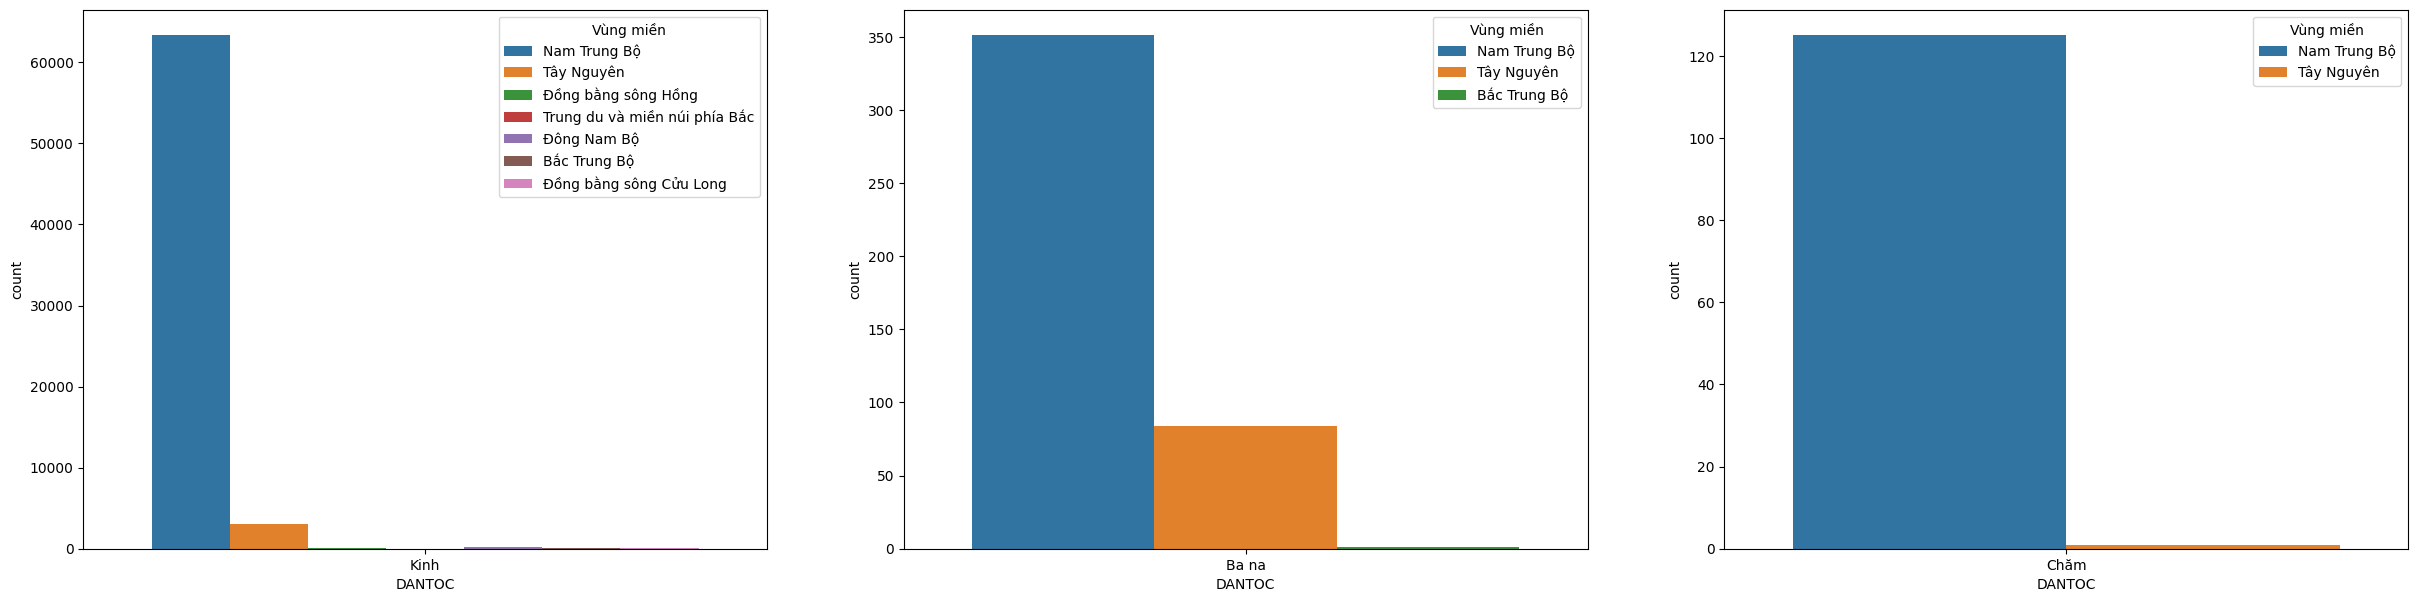

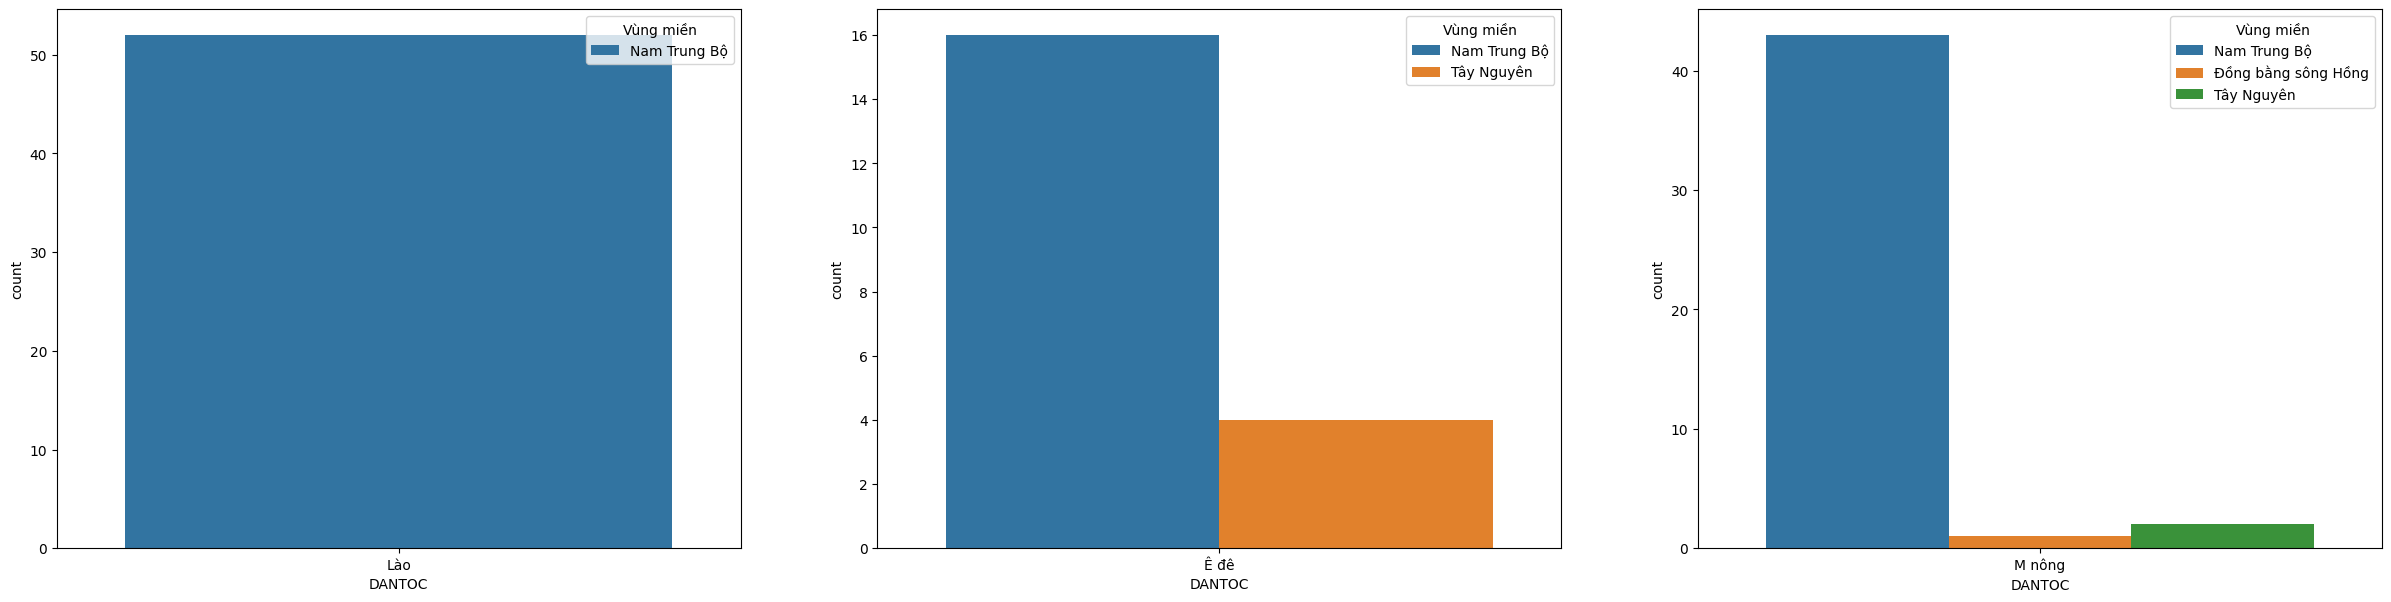

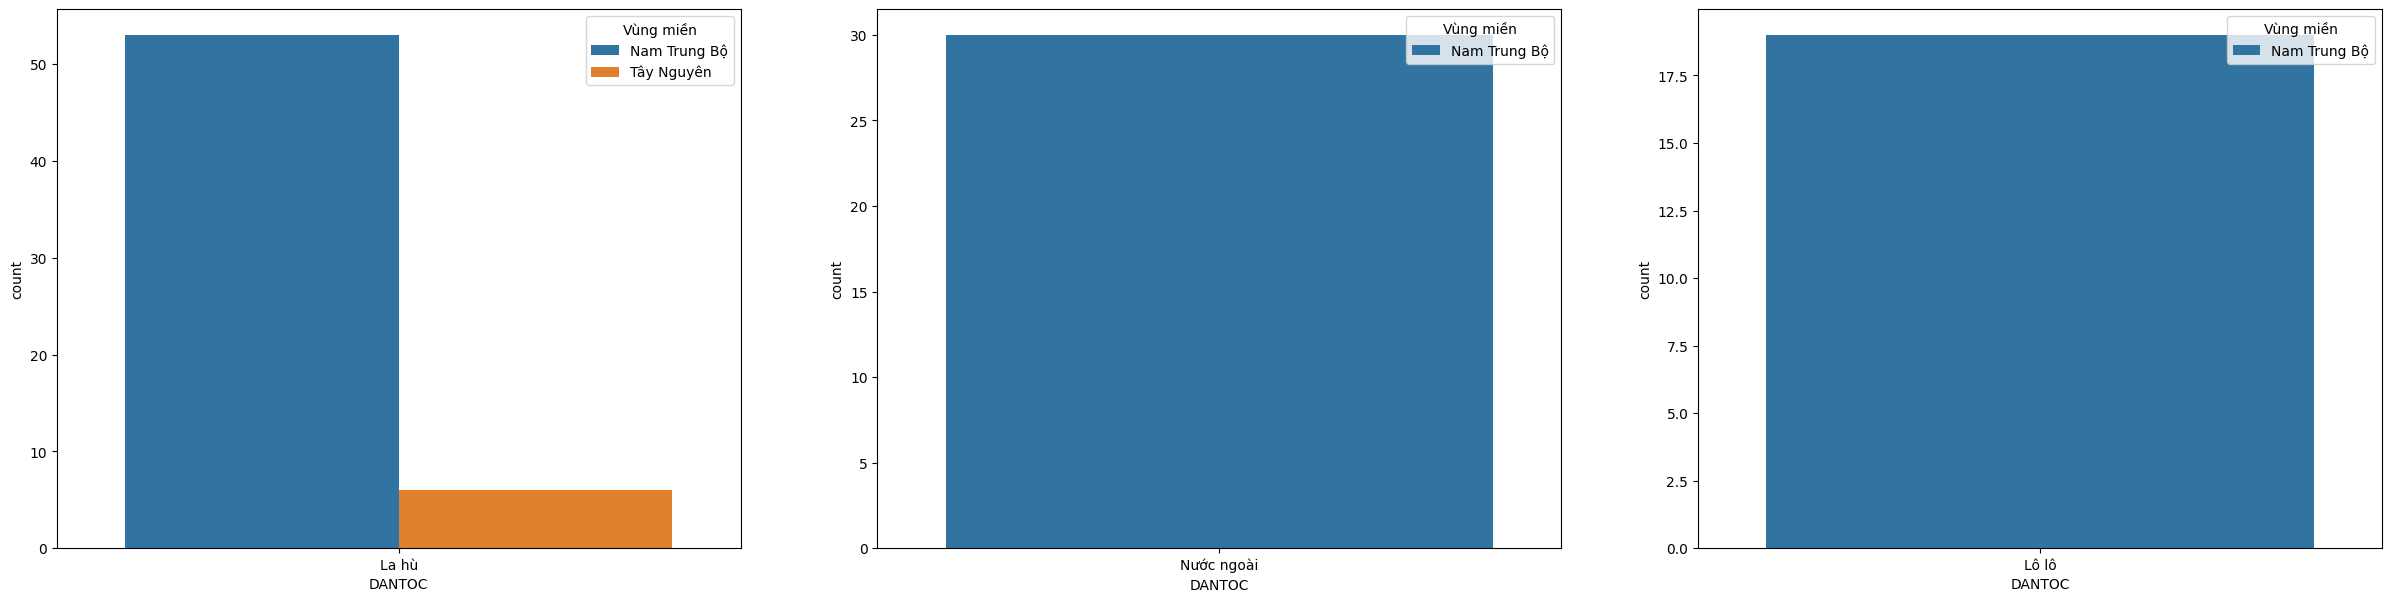

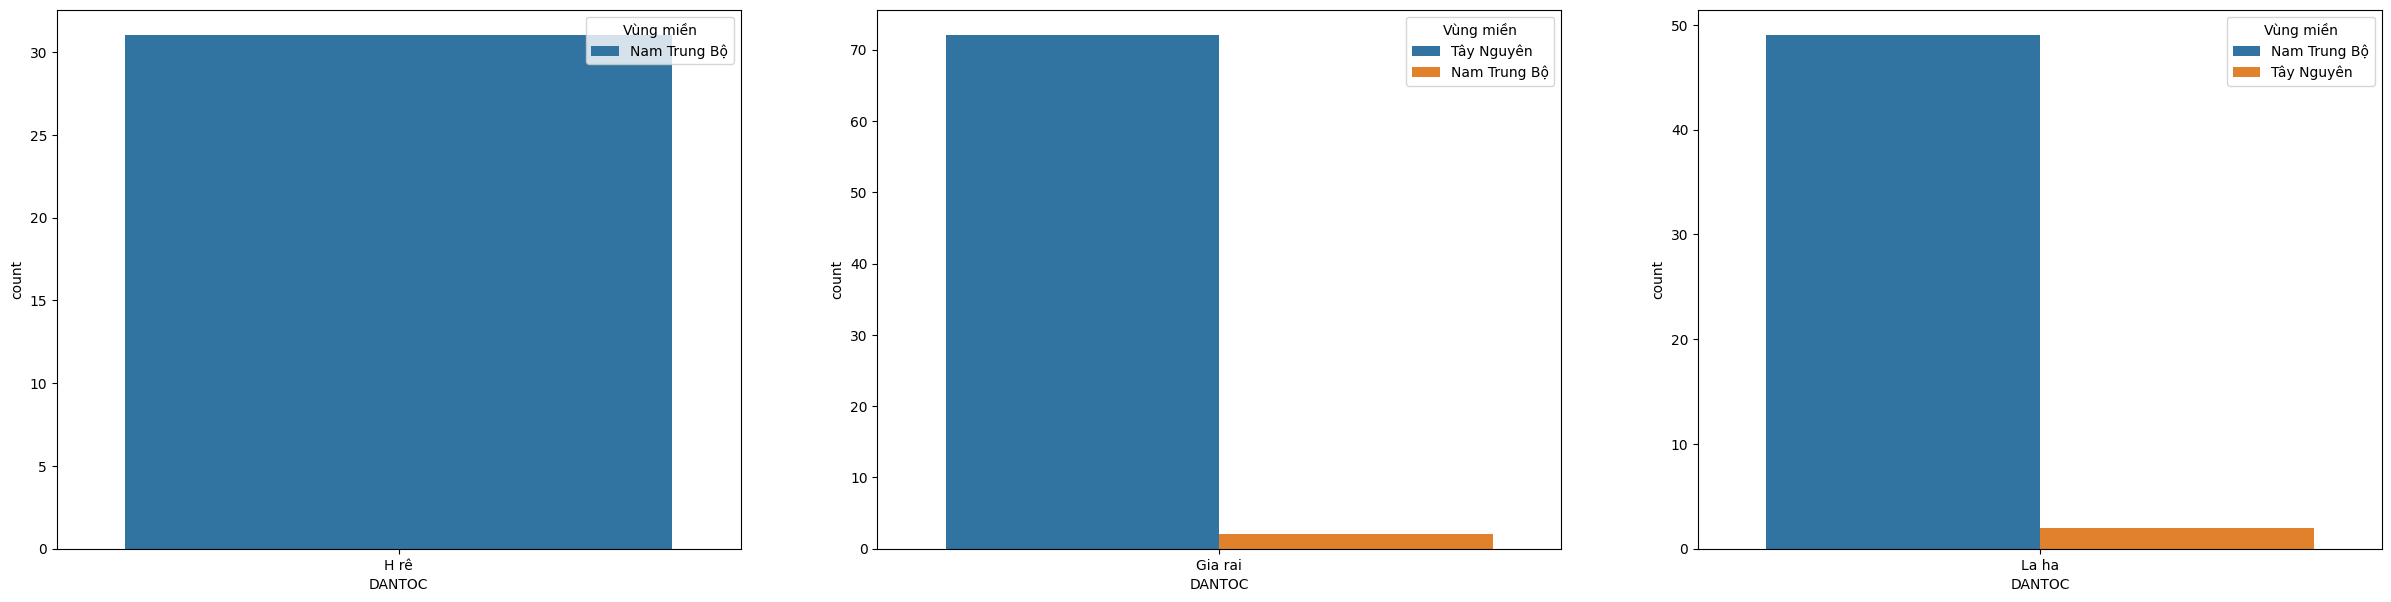

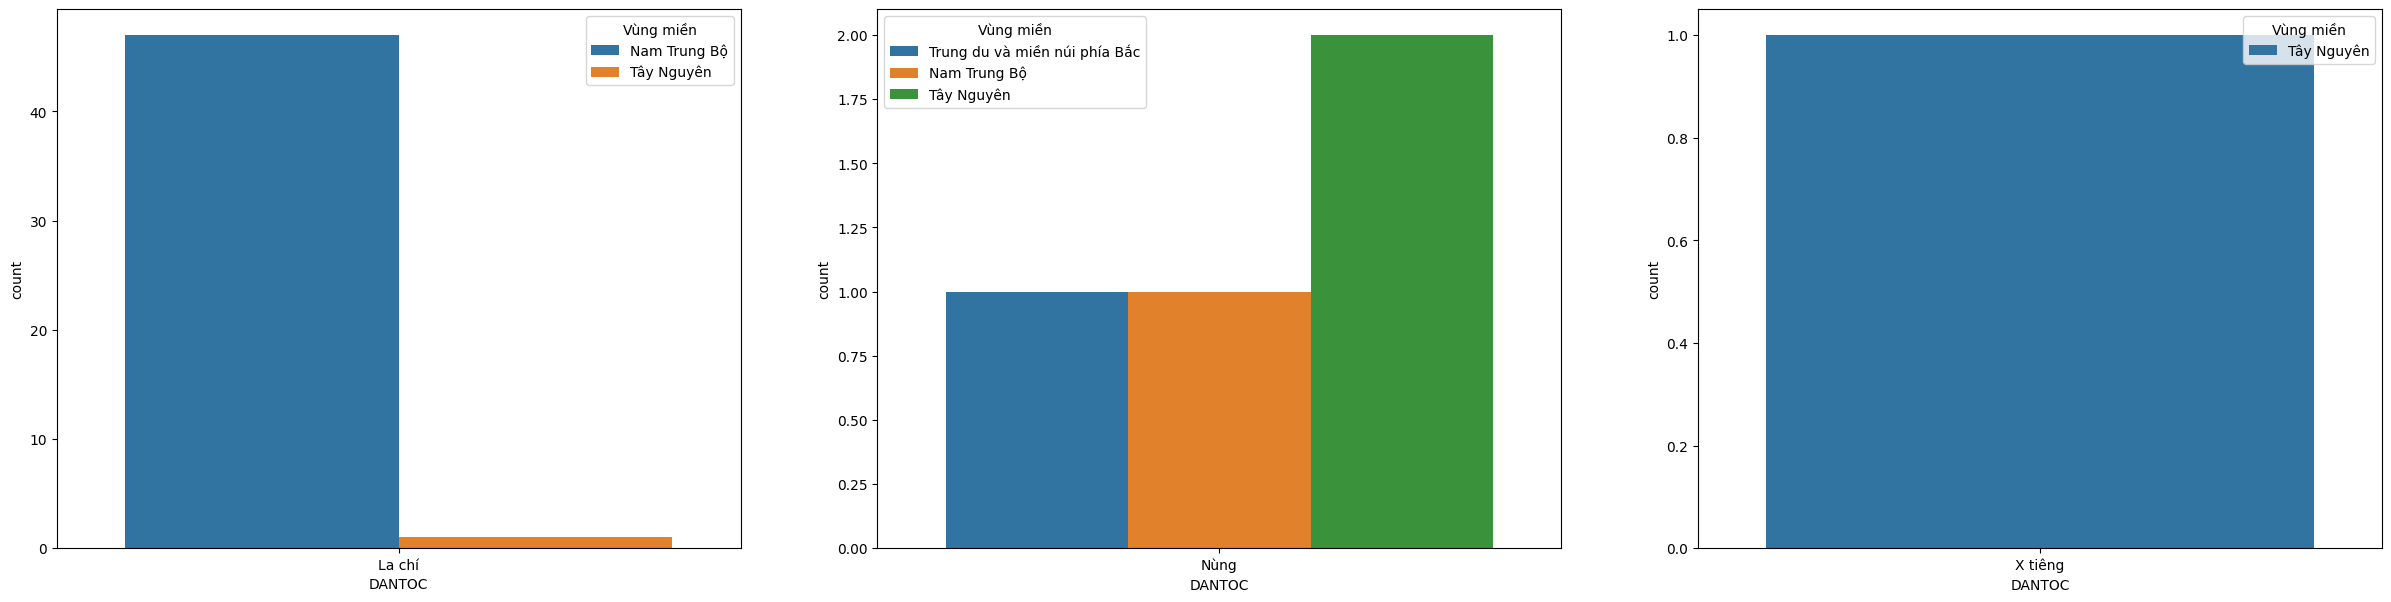

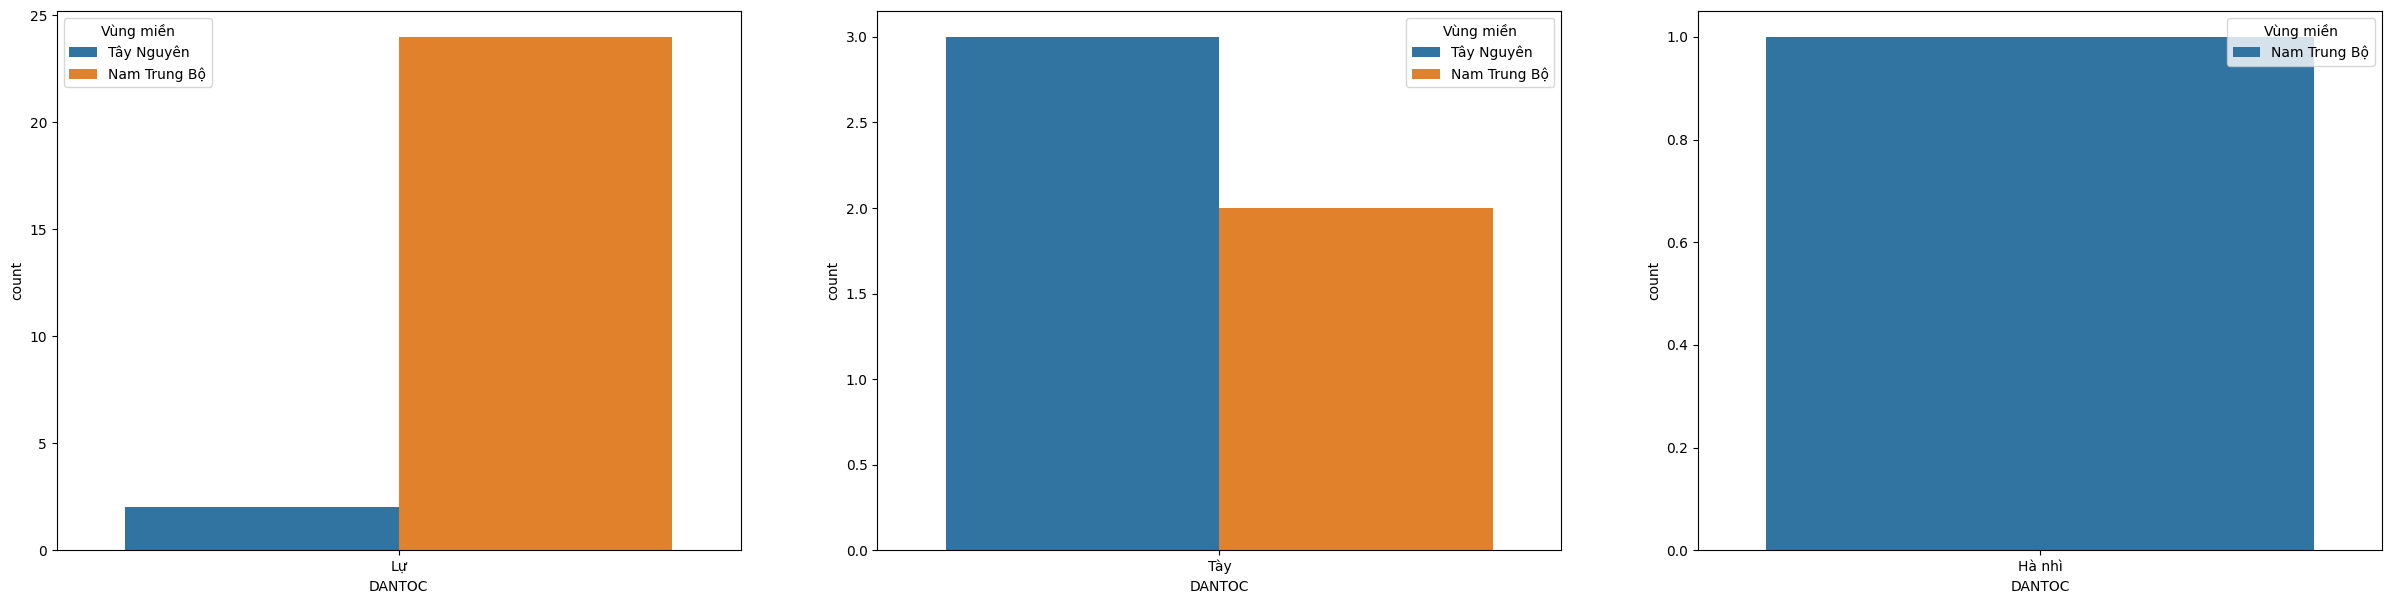

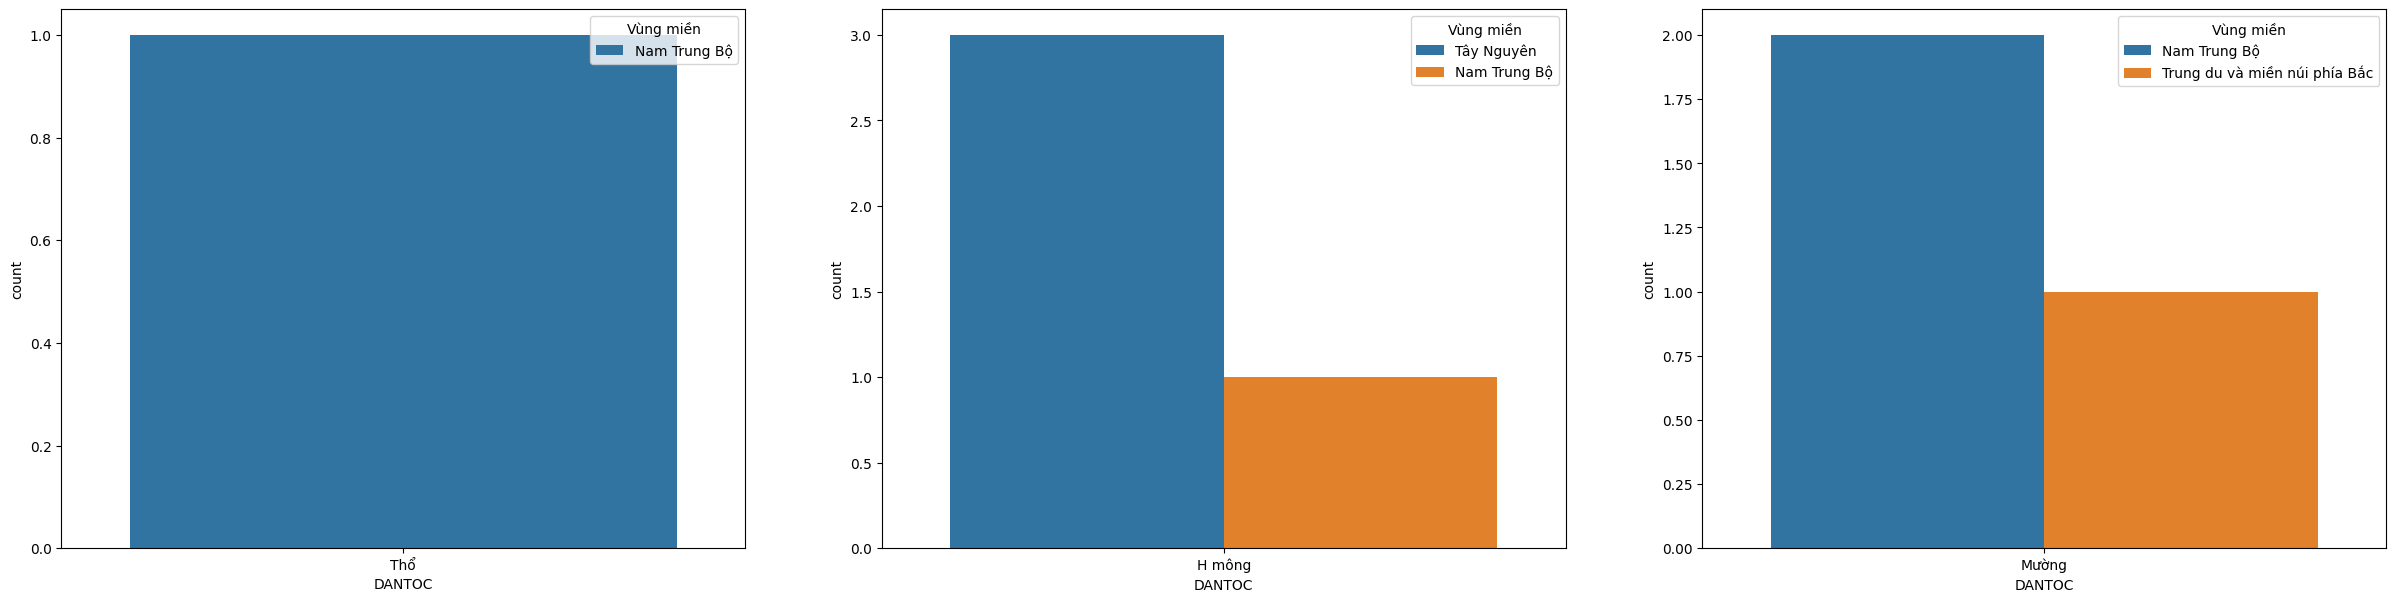

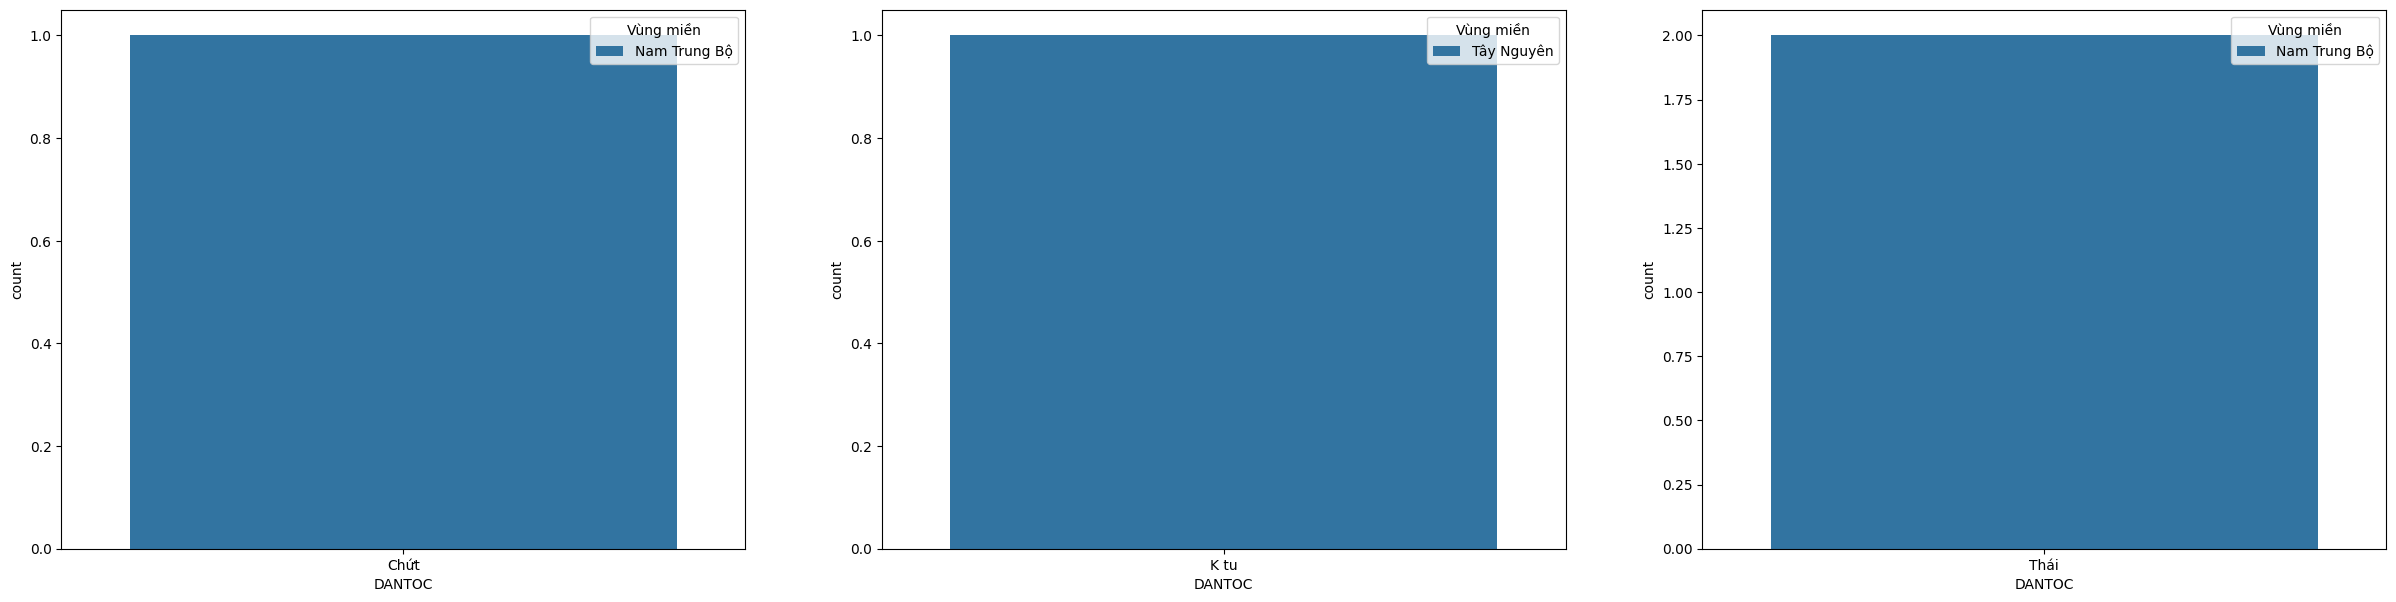

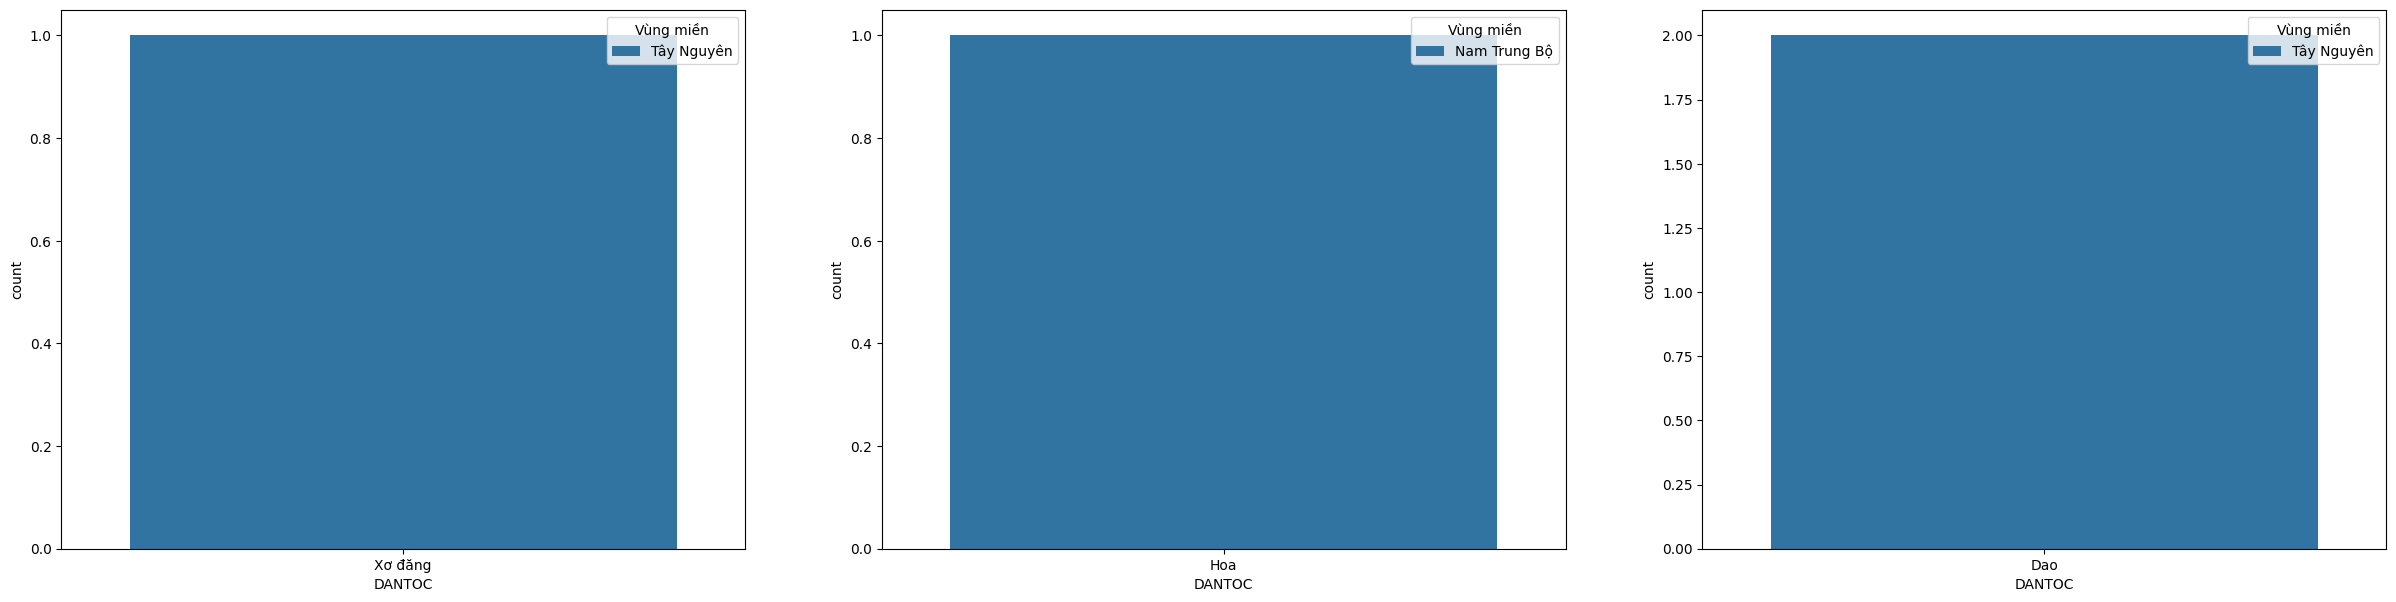

<Figure size 3000x700 with 0 Axes>

In [ ]:
def visualize():
  j = 1
  plt.figure(figsize = (30,7))
  for ethnic_group in ethnicity:
    plt.subplot(1,3,j)
    sns.countplot(data = df[df['DANTOC'] == ethnic_group], x = 'DANTOC', hue = 'Vùng miền')
    j += 1
    if (j % 3 == 1):
      plt.show()
      print('\n\n')
      j = 1
      plt.figure(figsize = (30,7))
  #plt.show()

visualize()

- Vì bệnh nhân chủ yếu đến từ các tỉnh Nam Trung Bộ nên sự phân bố dân tộc cũng có xu hướng tập trung nhiều ở vùng này. Ta có thể gộp thành 3 nhóm: dân tộc Kinh, dân tộc thiểu số và người nước ngoài

In [ ]:
df['DANTOC'] = list(map(lambda x: x if (x == 'Kinh' or x == 'Nước ngoài') else 'Dân tộc thiểu số',df['DANTOC']))

**Xem lại dữ liệu** sau khi đã gom nhóm dân tộc.

In [ ]:
df

,Tuổi,DANTOC,TENPXA,TENQUANHUYEN,TENTINHTHANH,MAICD,CHANDOAN,NGAYVAO,NGAYRA,TONGCP,BHYT_TT,Thời gian điều trị,Vùng miền
0,28,Kinh,PHƯỜNG NHƠN BÌNH,THÀNH PHỐ QUI NHƠN,BÌNH ĐỊNH,S01.1;,Vết thương hở của mi mắt và vùng quanh mắt;,2016-01-01 00:55:00,2016-01-01 01:04:00,1.500000e+04,0.000000e+00,0.006250,Nam Trung Bộ
1,18,Kinh,PHƯỜNG NHƠN PHÚ,THÀNH PHỐ QUI NHƠN,BÌNH ĐỊNH,I20;,Cơn đau thắt ngực;,2016-01-01 01:37:00,2016-01-01 03:23:00,8.334650e+04,8.334650e+04,0.073611,Nam Trung Bộ
2,36,Kinh,XÃ NHƠN LỘC,THỊ XÃ AN NHƠN,BÌNH ĐỊNH,J68.2;P71.0;,Viêm hô hấp trên;Hạ calci máu;,2016-01-01 03:31:00,2016-01-01 05:00:00,1.599990e+02,0.000000e+00,0.061806,Nam Trung Bộ
3,5,Kinh,PHƯỜNG TRẦN QUANG DIỆU,THÀNH PHỐ QUI NHƠN,BÌNH ĐỊNH,A91.A;,Sốt xuất huyết Dengue;,2015-12-29 20:25:00,2016-01-01 07:00:00,1.129380e+05,1.129380e+05,2.440972,Nam Trung Bộ
4,5,Kinh,PHƯỜNG NHƠN PHÚ,THÀNH PHỐ QUI NHƠN,BÌNH ĐỊNH,A91;J00;,Sốt xuất huyết Dengue;Viêm Họng Cấp;,2015-12-25 08:44:00,2016-01-01 07:00:00,2.623950e+05,2.623950e+05,6.927778,Nam Trung Bộ
...,...,...,...,...,...,...,...,...,...,...,...,...,...
68757,73,Kinh,PHƯỜNG TRẦN QUANG DIỆU,THÀNH PHỐ QUI NHƠN,BÌNH ĐỊNH,Y84.1;D63.0;,Chạy thận nhân tạo;Thiếu máu trong bệnh suy th...,2016-12-01 08:11:00,2016-12-31 23:00:00,1.102239e+07,1.102239e+07,30.617361,Nam Trung Bộ
68758,24,Dân tộc thiểu số,PHƯỜNG BÌNH ĐỊNH,THỊ XÃ AN NHƠN,BÌNH ĐỊNH,Y84.1;,Chạy thận nhân tạo;,2016-11-19 06:53:00,2016-12-31 23:00:00,1.359227e+07,1.359227e+07,42.671528,Nam Trung Bộ
68759,42,Kinh,XÃ NHƠN PHÚC,THỊ XÃ AN NHƠN,BÌNH ĐỊNH,Y84.1;,Chạy thận nhân tạo;,2016-11-19 06:52:00,2016-12-31 23:00:00,1.021012e+07,1.021012e+07,42.672222,Nam Trung Bộ
68760,40,Kinh,XÃ MỸ THỌ,HUYỆN PHÙ MỸ,BÌNH ĐỊNH,Y84.1;J18;,Chạy thận nhân tạo;Viêm phổi;,2016-11-10 06:56:00,2016-12-31 23:00:00,1.734061e+07,1.734061e+07,51.669444,Nam Trung Bộ


**Khảo sát tiền tố tên Phường/Xã**: tách từ đầu tiên (PHƯỜNG, XÃ, THỊ TRẤN…) và đếm tần suất để biết cách bóc tách tên thuần.

In [ ]:
df['TENPXA'].str.split(' ').str[0].value_counts()

,count
TENPXA,
XÃ,38166
PHƯỜNG,23976
THỊ,4586
PHƯỚC,402
TÂN,180
TT,163
KHÔNG,86
CƯ,84
ĐAK,76


**Bóc tách tên Phường/Xã thuần** từ `TENPXA` (làm trên bản sao `df1`): bỏ tiền tố hành chính — PHƯỜNG/XÃ/TT/XẢ bỏ 1 từ; THỊ TRẤN bỏ 2 từ; xử lý riêng trường hợp `P.XUÂN`.

In [ ]:
df1 = df.copy()
df1['Phường/Xã'] = list(map(lambda x: ' '.join(x.split(' ')[1:]) if (x.split(' ')[0] in ['PHƯỜNG','XÃ','TT','XẢ']) else
                                      ' '.join(x.split(' ')[2:]) if (x.split(' ')[0] == 'THỊ') else
                                      ' '.join(['XUÂN'] + x.split(' ')[1:]) if (x.split(' ')[0] == 'P.XUÂN') else x,df1['TENPXA']))

**Xử lý phường đánh số**: với tên phường chỉ gồm chữ số (vd '1', '2'), thêm tiền tố `'PHƯỜNG '` để tên có nghĩa (PHƯỜNG 1, PHƯỜNG 2…).

In [ ]:
#df1[df1['Phường/Xã'].str.isdigit()]['TENPXA'].str.split(" ").str[0].value_counts()
df1['Phường/Xã'] = list(map(lambda x: 'PHƯỜNG ' + x if x.isdigit() else x,df1['Phường/Xã']))

**Đếm số Phường/Xã** duy nhất sau khi chuẩn hóa, để kiểm tra mức độ rút gọn.

In [ ]:
df1['Phường/Xã'].nunique()

1054

**Khảo sát tiền tố tên Quận/Huyện** (HUYỆN, TP, THÀNH PHỐ, THỊ XÃ…) tương tự bước xử lý Phường/Xã.

In [ ]:
df1['TENQUANHUYEN'].str.split(' ').str[0].value_counts()

,count
TENQUANHUYEN,
HUYỆN,37134
THÀNH,22220
THỊ,8393
QUẬN,237
TP,28
TX,9
HOÀNG,9
PHÚ,2
LỘC,2


**Bóc tách tên Huyện/TP thuần** từ `TENQUANHUYEN`: bỏ tiền tố HUYỆN/TP/TX (1 từ) hoặc THÀNH PHỐ/THỊ XÃ (2 từ).

In [ ]:
df1['Huyện/TP'] = list(map(lambda x: ' '.join(x.split(' ')[1:]) if (x.split(' ')[0] in ['HUYỆN','TP','TX']) else
                                     ' '.join(x.split(' ')[2:]) if (x.split(' ')[0] in ['THÀNH','THỊ']) else x,df1['TENQUANHUYEN']))

**Xem lại dữ liệu** với hai cột địa danh đã chuẩn hóa (`Phường/Xã`, `Huyện/TP`).

In [ ]:
df1

,Tuổi,DANTOC,TENPXA,TENQUANHUYEN,TENTINHTHANH,MAICD,CHANDOAN,NGAYVAO,NGAYRA,TONGCP,BHYT_TT,Thời gian điều trị,Vùng miền,Phường/Xã,Huyện/TP
0,28,Kinh,PHƯỜNG NHƠN BÌNH,THÀNH PHỐ QUI NHƠN,BÌNH ĐỊNH,S01.1;,Vết thương hở của mi mắt và vùng quanh mắt;,2016-01-01 00:55:00,2016-01-01 01:04:00,1.500000e+04,0.000000e+00,0.006250,Nam Trung Bộ,NHƠN BÌNH,QUI NHƠN
1,18,Kinh,PHƯỜNG NHƠN PHÚ,THÀNH PHỐ QUI NHƠN,BÌNH ĐỊNH,I20;,Cơn đau thắt ngực;,2016-01-01 01:37:00,2016-01-01 03:23:00,8.334650e+04,8.334650e+04,0.073611,Nam Trung Bộ,NHƠN PHÚ,QUI NHƠN
2,36,Kinh,XÃ NHƠN LỘC,THỊ XÃ AN NHƠN,BÌNH ĐỊNH,J68.2;P71.0;,Viêm hô hấp trên;Hạ calci máu;,2016-01-01 03:31:00,2016-01-01 05:00:00,1.599990e+02,0.000000e+00,0.061806,Nam Trung Bộ,NHƠN LỘC,AN NHƠN
3,5,Kinh,PHƯỜNG TRẦN QUANG DIỆU,THÀNH PHỐ QUI NHƠN,BÌNH ĐỊNH,A91.A;,Sốt xuất huyết Dengue;,2015-12-29 20:25:00,2016-01-01 07:00:00,1.129380e+05,1.129380e+05,2.440972,Nam Trung Bộ,TRẦN QUANG DIỆU,QUI NHƠN
4,5,Kinh,PHƯỜNG NHƠN PHÚ,THÀNH PHỐ QUI NHƠN,BÌNH ĐỊNH,A91;J00;,Sốt xuất huyết Dengue;Viêm Họng Cấp;,2015-12-25 08:44:00,2016-01-01 07:00:00,2.623950e+05,2.623950e+05,6.927778,Nam Trung Bộ,NHƠN PHÚ,QUI NHƠN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68757,73,Kinh,PHƯỜNG TRẦN QUANG DIỆU,THÀNH PHỐ QUI NHƠN,BÌNH ĐỊNH,Y84.1;D63.0;,Chạy thận nhân tạo;Thiếu máu trong bệnh suy th...,2016-12-01 08:11:00,2016-12-31 23:00:00,1.102239e+07,1.102239e+07,30.617361,Nam Trung Bộ,TRẦN QUANG DIỆU,QUI NHƠN
68758,24,Dân tộc thiểu số,PHƯỜNG BÌNH ĐỊNH,THỊ XÃ AN NHƠN,BÌNH ĐỊNH,Y84.1;,Chạy thận nhân tạo;,2016-11-19 06:53:00,2016-12-31 23:00:00,1.359227e+07,1.359227e+07,42.671528,Nam Trung Bộ,BÌNH ĐỊNH,AN NHƠN
68759,42,Kinh,XÃ NHƠN PHÚC,THỊ XÃ AN NHƠN,BÌNH ĐỊNH,Y84.1;,Chạy thận nhân tạo;,2016-11-19 06:52:00,2016-12-31 23:00:00,1.021012e+07,1.021012e+07,42.672222,Nam Trung Bộ,NHƠN PHÚC,AN NHƠN
68760,40,Kinh,XÃ MỸ THỌ,HUYỆN PHÙ MỸ,BÌNH ĐỊNH,Y84.1;J18;,Chạy thận nhân tạo;Viêm phổi;,2016-11-10 06:56:00,2016-12-31 23:00:00,1.734061e+07,1.734061e+07,51.669444,Nam Trung Bộ,MỸ THỌ,PHÙ MỸ


**Tạo bảng địa chỉ duy nhất** `df2`: lấy các tổ hợp (Phường/Xã, Huyện/TP, Tỉnh) không trùng và ghép thành chuỗi `'Địa chỉ'` đầy đủ (bỏ phần Phường/Xã nếu là `KHÔNG XÁC ĐỊNH`). Đây là bước chuẩn bị để **lấy tọa độ (geocode) và join với `address_df_full.csv`** ở phần tiếp theo.

In [ ]:
df2 = df1[['Phường/Xã','Huyện/TP','TENTINHTHANH']].drop_duplicates()
df2['Địa chỉ'] = list(map(lambda x,y,z: x + ',' + y + ',' + z if (x != 'KHÔNG XÁC ĐỊNH') else
                                   y + ',' + z, df2['Phường/Xã'], df2['Huyện/TP'], df2['TENTINHTHANH']))
df2.reset_index(drop = True, inplace = True)
df2

,Phường/Xã,Huyện/TP,TENTINHTHANH,Địa chỉ
0,NHƠN BÌNH,QUI NHƠN,BÌNH ĐỊNH,"NHƠN BÌNH,QUI NHƠN,BÌNH ĐỊNH"
1,NHƠN PHÚ,QUI NHƠN,BÌNH ĐỊNH,"NHƠN PHÚ,QUI NHƠN,BÌNH ĐỊNH"
2,NHƠN LỘC,AN NHƠN,BÌNH ĐỊNH,"NHƠN LỘC,AN NHƠN,BÌNH ĐỊNH"
3,TRẦN QUANG DIỆU,QUI NHƠN,BÌNH ĐỊNH,"TRẦN QUANG DIỆU,QUI NHƠN,BÌNH ĐỊNH"
4,DIÊU TRÌ,TUY PHƯỚC,BÌNH ĐỊNH,"DIÊU TRÌ,TUY PHƯỚC,BÌNH ĐỊNH"
...,...,...,...,...
1252,ĐÔNG THẠNH,CẦN GIUỘC,LONG AN,"ĐÔNG THẠNH,CẦN GIUỘC,LONG AN"
1253,THANH TRÌ,THANH TRÌ,HÀ NỘI,"THANH TRÌ,THANH TRÌ,HÀ NỘI"
1254,LỘC THỦY,PHÚ LỘC,THỪA THIÊN - HUẾ,"LỘC THỦY,PHÚ LỘC,THỪA THIÊN - HUẾ"
1255,VĨNH THANH,RẠCH GIÁ,KIÊN GIANG,"VĨNH THANH,RẠCH GIÁ,KIÊN GIANG"


In [ ]:
coordinate = pd.read_csv('/content/drive/MyDrive/My Own Projects/Disease (2024)/address_df_full.csv')
coordinate

,Địa chỉ mới,Tọa độ,level,kinh độ,vĩ độ
0,"NHƠN BÌNH,QUI NHƠN,BÌNH ĐỊNH","(13.7930532, 109.1916057)",1,109.191606,13.793053
1,"NHƠN PHÚ,QUI NHƠN,BÌNH ĐỊNH","(13.7945583, 109.1813114)",1,109.181311,13.794558
2,"NHƠN LỘC,AN NHƠN,BÌNH ĐỊNH","(13.8789863, 109.0686007)",1,109.068601,13.878986
3,"TRẦN QUANG DIỆU,QUI NHƠN,BÌNH ĐỊNH","(13.786352, 109.1482711)",1,109.148271,13.786352
4,"DIÊU TRÌ,TUY PHƯỚC,BÌNH ĐỊNH","(13.8071597, 109.1437149)",1,109.143715,13.807160
...,...,...,...,...,...
1252,"ĐÔNG THẠNH,CẦN GIUỘC,LONG AN","(10.5295518, 106.6724105)",1,106.672410,10.529552
1253,"THANH TRÌ,THANH TRÌ,HÀ NỘI","(20.94805855, 105.84967889687385)",1,105.849679,20.948059
1254,"LỘC THỦY,PHÚ LỘC,THỪA THIÊN - HUẾ","(16.2706984, 107.9277907)",1,107.927791,16.270698
1255,"VĨNH THANH,RẠCH GIÁ,KIÊN GIANG","(10.0153837, 105.0831127)",1,105.083113,10.015384


In [ ]:
concat_df = pd.concat([df2,coordinate], axis = 1)
concat_df

,Phường/Xã,Huyện/TP,TENTINHTHANH,Địa chỉ,Địa chỉ mới,Tọa độ,level,kinh độ,vĩ độ
0,NHƠN BÌNH,QUI NHƠN,BÌNH ĐỊNH,"NHƠN BÌNH,QUI NHƠN,BÌNH ĐỊNH","NHƠN BÌNH,QUI NHƠN,BÌNH ĐỊNH","(13.7930532, 109.1916057)",1,109.191606,13.793053
1,NHƠN PHÚ,QUI NHƠN,BÌNH ĐỊNH,"NHƠN PHÚ,QUI NHƠN,BÌNH ĐỊNH","NHƠN PHÚ,QUI NHƠN,BÌNH ĐỊNH","(13.7945583, 109.1813114)",1,109.181311,13.794558
2,NHƠN LỘC,AN NHƠN,BÌNH ĐỊNH,"NHƠN LỘC,AN NHƠN,BÌNH ĐỊNH","NHƠN LỘC,AN NHƠN,BÌNH ĐỊNH","(13.8789863, 109.0686007)",1,109.068601,13.878986
3,TRẦN QUANG DIỆU,QUI NHƠN,BÌNH ĐỊNH,"TRẦN QUANG DIỆU,QUI NHƠN,BÌNH ĐỊNH","TRẦN QUANG DIỆU,QUI NHƠN,BÌNH ĐỊNH","(13.786352, 109.1482711)",1,109.148271,13.786352
4,DIÊU TRÌ,TUY PHƯỚC,BÌNH ĐỊNH,"DIÊU TRÌ,TUY PHƯỚC,BÌNH ĐỊNH","DIÊU TRÌ,TUY PHƯỚC,BÌNH ĐỊNH","(13.8071597, 109.1437149)",1,109.143715,13.807160
...,...,...,...,...,...,...,...,...,...
1252,ĐÔNG THẠNH,CẦN GIUỘC,LONG AN,"ĐÔNG THẠNH,CẦN GIUỘC,LONG AN","ĐÔNG THẠNH,CẦN GIUỘC,LONG AN","(10.5295518, 106.6724105)",1,106.672410,10.529552
1253,THANH TRÌ,THANH TRÌ,HÀ NỘI,"THANH TRÌ,THANH TRÌ,HÀ NỘI","THANH TRÌ,THANH TRÌ,HÀ NỘI","(20.94805855, 105.84967889687385)",1,105.849679,20.948059
1254,LỘC THỦY,PHÚ LỘC,THỪA THIÊN - HUẾ,"LỘC THỦY,PHÚ LỘC,THỪA THIÊN - HUẾ","LỘC THỦY,PHÚ LỘC,THỪA THIÊN - HUẾ","(16.2706984, 107.9277907)",1,107.927791,16.270698
1255,VĨNH THANH,RẠCH GIÁ,KIÊN GIANG,"VĨNH THANH,RẠCH GIÁ,KIÊN GIANG","VĨNH THANH,RẠCH GIÁ,KIÊN GIANG","(10.0153837, 105.0831127)",1,105.083113,10.015384


In [ ]:
df1['Địa chỉ'] = list(map(lambda x,y,z: x + ',' + y + ',' + z if (x != 'KHÔNG XÁC ĐỊNH') else
                                        y + ',' + z, df1['Phường/Xã'], df1['Huyện/TP'], df1['TENTINHTHANH']))
df1 = df1.drop(columns = ['TENPXA','TENQUANHUYEN'])
df1

,Tuổi,DANTOC,TENTINHTHANH,MAICD,CHANDOAN,NGAYVAO,NGAYRA,TONGCP,BHYT_TT,Thời gian điều trị,Vùng miền,Phường/Xã,Huyện/TP,Địa chỉ
0,28,Kinh,BÌNH ĐỊNH,S01.1;,Vết thương hở của mi mắt và vùng quanh mắt;,2016-01-01 00:55:00,2016-01-01 01:04:00,1.500000e+04,0.000000e+00,0.006250,Nam Trung Bộ,NHƠN BÌNH,QUI NHƠN,"NHƠN BÌNH,QUI NHƠN,BÌNH ĐỊNH"
1,18,Kinh,BÌNH ĐỊNH,I20;,Cơn đau thắt ngực;,2016-01-01 01:37:00,2016-01-01 03:23:00,8.334650e+04,8.334650e+04,0.073611,Nam Trung Bộ,NHƠN PHÚ,QUI NHƠN,"NHƠN PHÚ,QUI NHƠN,BÌNH ĐỊNH"
2,36,Kinh,BÌNH ĐỊNH,J68.2;P71.0;,Viêm hô hấp trên;Hạ calci máu;,2016-01-01 03:31:00,2016-01-01 05:00:00,1.599990e+02,0.000000e+00,0.061806,Nam Trung Bộ,NHƠN LỘC,AN NHƠN,"NHƠN LỘC,AN NHƠN,BÌNH ĐỊNH"
3,5,Kinh,BÌNH ĐỊNH,A91.A;,Sốt xuất huyết Dengue;,2015-12-29 20:25:00,2016-01-01 07:00:00,1.129380e+05,1.129380e+05,2.440972,Nam Trung Bộ,TRẦN QUANG DIỆU,QUI NHƠN,"TRẦN QUANG DIỆU,QUI NHƠN,BÌNH ĐỊNH"
4,5,Kinh,BÌNH ĐỊNH,A91;J00;,Sốt xuất huyết Dengue;Viêm Họng Cấp;,2015-12-25 08:44:00,2016-01-01 07:00:00,2.623950e+05,2.623950e+05,6.927778,Nam Trung Bộ,NHƠN PHÚ,QUI NHƠN,"NHƠN PHÚ,QUI NHƠN,BÌNH ĐỊNH"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68757,73,Kinh,BÌNH ĐỊNH,Y84.1;D63.0;,Chạy thận nhân tạo;Thiếu máu trong bệnh suy th...,2016-12-01 08:11:00,2016-12-31 23:00:00,1.102239e+07,1.102239e+07,30.617361,Nam Trung Bộ,TRẦN QUANG DIỆU,QUI NHƠN,"TRẦN QUANG DIỆU,QUI NHƠN,BÌNH ĐỊNH"
68758,24,Dân tộc thiểu số,BÌNH ĐỊNH,Y84.1;,Chạy thận nhân tạo;,2016-11-19 06:53:00,2016-12-31 23:00:00,1.359227e+07,1.359227e+07,42.671528,Nam Trung Bộ,BÌNH ĐỊNH,AN NHƠN,"BÌNH ĐỊNH,AN NHƠN,BÌNH ĐỊNH"
68759,42,Kinh,BÌNH ĐỊNH,Y84.1;,Chạy thận nhân tạo;,2016-11-19 06:52:00,2016-12-31 23:00:00,1.021012e+07,1.021012e+07,42.672222,Nam Trung Bộ,NHƠN PHÚC,AN NHƠN,"NHƠN PHÚC,AN NHƠN,BÌNH ĐỊNH"
68760,40,Kinh,BÌNH ĐỊNH,Y84.1;J18;,Chạy thận nhân tạo;Viêm phổi;,2016-11-10 06:56:00,2016-12-31 23:00:00,1.734061e+07,1.734061e+07,51.669444,Nam Trung Bộ,MỸ THỌ,PHÙ MỸ,"MỸ THỌ,PHÙ MỸ,BÌNH ĐỊNH"


In [ ]:
df1['Kinh độ'] = [concat_df[concat_df['Địa chỉ'] == x]['kinh độ'].iloc[0] for x in df1['Địa chỉ']]
df1['Vĩ độ'] = [concat_df[concat_df['Địa chỉ'] == x]['vĩ độ'].iloc[0] for x in df1['Địa chỉ']]
df1['level'] = [concat_df[concat_df['Địa chỉ'] == x]['level'].iloc[0] for x in df1['Địa chỉ']]

In [ ]:
df1['Kinh độ'] = list(map(lambda x,y: x if (y == 1) else x + np.random.uniform(0.001,0.002),df1['Kinh độ'],df1['level']))
df1['Vĩ độ'] = list(map(lambda x,y: x if (y == 1) else x + np.random.uniform(0.001,0.002),df1['Vĩ độ'],df1['level']))

In [ ]:
df1 = df1.dropna(subset = ['Kinh độ'])
df1

,Tuổi,DANTOC,TENTINHTHANH,MAICD,CHANDOAN,NGAYVAO,NGAYRA,TONGCP,BHYT_TT,Thời gian điều trị,Vùng miền,Phường/Xã,Huyện/TP,Địa chỉ,Kinh độ,Vĩ độ,level
0,28,Kinh,BÌNH ĐỊNH,S01.1;,Vết thương hở của mi mắt và vùng quanh mắt;,2016-01-01 00:55:00,2016-01-01 01:04:00,1.500000e+04,0.000000e+00,0.006250,Nam Trung Bộ,NHƠN BÌNH,QUI NHƠN,"NHƠN BÌNH,QUI NHƠN,BÌNH ĐỊNH",109.191606,13.793053,1
1,18,Kinh,BÌNH ĐỊNH,I20;,Cơn đau thắt ngực;,2016-01-01 01:37:00,2016-01-01 03:23:00,8.334650e+04,8.334650e+04,0.073611,Nam Trung Bộ,NHƠN PHÚ,QUI NHƠN,"NHƠN PHÚ,QUI NHƠN,BÌNH ĐỊNH",109.181311,13.794558,1
2,36,Kinh,BÌNH ĐỊNH,J68.2;P71.0;,Viêm hô hấp trên;Hạ calci máu;,2016-01-01 03:31:00,2016-01-01 05:00:00,1.599990e+02,0.000000e+00,0.061806,Nam Trung Bộ,NHƠN LỘC,AN NHƠN,"NHƠN LỘC,AN NHƠN,BÌNH ĐỊNH",109.068601,13.878986,1
3,5,Kinh,BÌNH ĐỊNH,A91.A;,Sốt xuất huyết Dengue;,2015-12-29 20:25:00,2016-01-01 07:00:00,1.129380e+05,1.129380e+05,2.440972,Nam Trung Bộ,TRẦN QUANG DIỆU,QUI NHƠN,"TRẦN QUANG DIỆU,QUI NHƠN,BÌNH ĐỊNH",109.148271,13.786352,1
4,5,Kinh,BÌNH ĐỊNH,A91;J00;,Sốt xuất huyết Dengue;Viêm Họng Cấp;,2015-12-25 08:44:00,2016-01-01 07:00:00,2.623950e+05,2.623950e+05,6.927778,Nam Trung Bộ,NHƠN PHÚ,QUI NHƠN,"NHƠN PHÚ,QUI NHƠN,BÌNH ĐỊNH",109.181311,13.794558,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68757,73,Kinh,BÌNH ĐỊNH,Y84.1;D63.0;,Chạy thận nhân tạo;Thiếu máu trong bệnh suy th...,2016-12-01 08:11:00,2016-12-31 23:00:00,1.102239e+07,1.102239e+07,30.617361,Nam Trung Bộ,TRẦN QUANG DIỆU,QUI NHƠN,"TRẦN QUANG DIỆU,QUI NHƠN,BÌNH ĐỊNH",109.148271,13.786352,1
68758,24,Dân tộc thiểu số,BÌNH ĐỊNH,Y84.1;,Chạy thận nhân tạo;,2016-11-19 06:53:00,2016-12-31 23:00:00,1.359227e+07,1.359227e+07,42.671528,Nam Trung Bộ,BÌNH ĐỊNH,AN NHƠN,"BÌNH ĐỊNH,AN NHƠN,BÌNH ĐỊNH",109.101382,13.887191,1
68759,42,Kinh,BÌNH ĐỊNH,Y84.1;,Chạy thận nhân tạo;,2016-11-19 06:52:00,2016-12-31 23:00:00,1.021012e+07,1.021012e+07,42.672222,Nam Trung Bộ,NHƠN PHÚC,AN NHƠN,"NHƠN PHÚC,AN NHƠN,BÌNH ĐỊNH",109.030093,13.906113,1
68760,40,Kinh,BÌNH ĐỊNH,Y84.1;J18;,Chạy thận nhân tạo;Viêm phổi;,2016-11-10 06:56:00,2016-12-31 23:00:00,1.734061e+07,1.734061e+07,51.669444,Nam Trung Bộ,MỸ THỌ,PHÙ MỸ,"MỸ THỌ,PHÙ MỸ,BÌNH ĐỊNH",109.148393,14.220117,1


In [ ]:
df1['MAICD'].str[-1].value_counts()

,count
MAICD,
;,67850
3,106
5,24
7,16
2,9
1,7
0,6
4,5
9,2


In [ ]:
df1['MAICD'] = list(map(lambda x: x if x[-1] == ';' else x + ';',df1['MAICD']))

In [ ]:
df1['Số lượng bệnh/hỗ trợ y tế'] = [len(x) + 1 if (len(x) == 0) else len(x) for x in df1['MAICD'].str.split(';').str[0:-1]]
df1

,Tuổi,DANTOC,TENTINHTHANH,MAICD,CHANDOAN,NGAYVAO,NGAYRA,TONGCP,BHYT_TT,Thời gian điều trị,Vùng miền,Phường/Xã,Huyện/TP,Địa chỉ,Kinh độ,Vĩ độ,level,Số lượng bệnh/hỗ trợ y tế
0,28,Kinh,BÌNH ĐỊNH,S01.1;,Vết thương hở của mi mắt và vùng quanh mắt;,2016-01-01 00:55:00,2016-01-01 01:04:00,1.500000e+04,0.000000e+00,0.006250,Nam Trung Bộ,NHƠN BÌNH,QUI NHƠN,"NHƠN BÌNH,QUI NHƠN,BÌNH ĐỊNH",109.191606,13.793053,1,1
1,18,Kinh,BÌNH ĐỊNH,I20;,Cơn đau thắt ngực;,2016-01-01 01:37:00,2016-01-01 03:23:00,8.334650e+04,8.334650e+04,0.073611,Nam Trung Bộ,NHƠN PHÚ,QUI NHƠN,"NHƠN PHÚ,QUI NHƠN,BÌNH ĐỊNH",109.181311,13.794558,1,1
2,36,Kinh,BÌNH ĐỊNH,J68.2;P71.0;,Viêm hô hấp trên;Hạ calci máu;,2016-01-01 03:31:00,2016-01-01 05:00:00,1.599990e+02,0.000000e+00,0.061806,Nam Trung Bộ,NHƠN LỘC,AN NHƠN,"NHƠN LỘC,AN NHƠN,BÌNH ĐỊNH",109.068601,13.878986,1,2
3,5,Kinh,BÌNH ĐỊNH,A91.A;,Sốt xuất huyết Dengue;,2015-12-29 20:25:00,2016-01-01 07:00:00,1.129380e+05,1.129380e+05,2.440972,Nam Trung Bộ,TRẦN QUANG DIỆU,QUI NHƠN,"TRẦN QUANG DIỆU,QUI NHƠN,BÌNH ĐỊNH",109.148271,13.786352,1,1
4,5,Kinh,BÌNH ĐỊNH,A91;J00;,Sốt xuất huyết Dengue;Viêm Họng Cấp;,2015-12-25 08:44:00,2016-01-01 07:00:00,2.623950e+05,2.623950e+05,6.927778,Nam Trung Bộ,NHƠN PHÚ,QUI NHƠN,"NHƠN PHÚ,QUI NHƠN,BÌNH ĐỊNH",109.181311,13.794558,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68757,73,Kinh,BÌNH ĐỊNH,Y84.1;D63.0;,Chạy thận nhân tạo;Thiếu máu trong bệnh suy th...,2016-12-01 08:11:00,2016-12-31 23:00:00,1.102239e+07,1.102239e+07,30.617361,Nam Trung Bộ,TRẦN QUANG DIỆU,QUI NHƠN,"TRẦN QUANG DIỆU,QUI NHƠN,BÌNH ĐỊNH",109.148271,13.786352,1,2
68758,24,Dân tộc thiểu số,BÌNH ĐỊNH,Y84.1;,Chạy thận nhân tạo;,2016-11-19 06:53:00,2016-12-31 23:00:00,1.359227e+07,1.359227e+07,42.671528,Nam Trung Bộ,BÌNH ĐỊNH,AN NHƠN,"BÌNH ĐỊNH,AN NHƠN,BÌNH ĐỊNH",109.101382,13.887191,1,1
68759,42,Kinh,BÌNH ĐỊNH,Y84.1;,Chạy thận nhân tạo;,2016-11-19 06:52:00,2016-12-31 23:00:00,1.021012e+07,1.021012e+07,42.672222,Nam Trung Bộ,NHƠN PHÚC,AN NHƠN,"NHƠN PHÚC,AN NHƠN,BÌNH ĐỊNH",109.030093,13.906113,1,1
68760,40,Kinh,BÌNH ĐỊNH,Y84.1;J18;,Chạy thận nhân tạo;Viêm phổi;,2016-11-10 06:56:00,2016-12-31 23:00:00,1.734061e+07,1.734061e+07,51.669444,Nam Trung Bộ,MỸ THỌ,PHÙ MỸ,"MỸ THỌ,PHÙ MỸ,BÌNH ĐỊNH",109.148393,14.220117,1,2


In [ ]:
def test():
  codes = df1['MAICD'].str.split(';').str[0:-1]
  codes_list = [x for code in codes for x in code]
  codes_list = list(set(codes_list))
  codes_list.sort()
  return codes_list

test()

['A00',
 'A01',
 'A01.0',
 'A02',
 'A02.0',
 'A02.1',
 'A02.8',
 'A03',
 'A03.9',
 'A04',
 'A04.0',
 'A04.5',
 'A04.8',
 'A04.9',
 'A05',
 'A05.1',
 'A06',
 'A06.0',
 'A06.1',
 'A06.2',
 'A06.3',
 'A06.4',
 'A06.5',
 'A06.6',
 'A08',
 'A08.0',
 'A08.3',
 'A08.5',
 'A09',
 'A09.0',
 'A09.9',
 'A15',
 'A15.0',
 'A15.1',
 'A15.2',
 'A15.3',
 'A15.4',
 'A15.6',
 'A16.0',
 'A16.1',
 'A16.2',
 'A16.4',
 'A17',
 'A17.0',
 'A18',
 'A18.0',
 'A18.3',
 'A19',
 'A20.3',
 'A20.7',
 'A21.0',
 'A23.1',
 'A24.3',
 'A25',
 'A26.7',
 'A28.1',
 'A28.8',
 'A31',
 'A31.8',
 'A32.0',
 'A32.1',
 'A32.9',
 'A33',
 'A35',
 'A37',
 'A37.9',
 'A39.0',
 'A39.1',
 'A40',
 'A40.9',
 'A41',
 'A41.0',
 'A41.2',
 'A41.4',
 'A41.8',
 'A41.9',
 'A42',
 'A48',
 'A48.3',
 'A48.4',
 'A48.8',
 'A49',
 'A49.0',
 'A49.8',
 'A49.9',
 'A54.2',
 'A54.5',
 'A55',
 'A57',
 'A58',
 'A68',
 'A68.0',
 'A68.9',
 'A69.0',
 'A74.0',
 'A75',
 'A75.2',
 'A75.9',
 'A77.2',
 'A78',
 'A79.0',
 'A79.8',
 'A80.3',
 'A81.1',
 'A82',
 'A82.9',


In [ ]:
!pip install roman
import roman

In [ ]:
def ICD(code):
  code = code[:3]
  code_range = [
      ('A00','B99'), ('C00','D49'), ('D50','D89'), ('E00','E89'), ('F00','F99'), ('G00','G99'), ('H00','H59'), ('H60','H95'),
      ('I00','I99'), ('J00','J99'), ('K00','K95'), ('L00','L99'), ('M00','M99'), ('N00','N99'), ('O00','O9A'), ('P00','P96'),
      ('Q00','Q99'), ('R00','R99'), ('S00','T98'), ('U00','U85'), ('V00','Y99'), ('Z00','Z99')
      ]
  for index in range(len(code_range)):
    if code >= code_range[index][0] and code <= code_range[index][1]:
      return roman.toRoman(index + 1)
  return None

In [ ]:
df1['MAICD'] = df1['MAICD'].str.split(';').str[0:-1]
df1['Danh mục'] = df1['MAICD'].apply(lambda x: [ICD(code) for code in x])
for i in range(1,23):
  df1['Số lượng danh mục bệnh %s'%(roman.toRoman(i))] = [x.count(roman.toRoman(i)) for x in df1['Danh mục']]

In [ ]:
df1

,Tuổi,DANTOC,TENTINHTHANH,MAICD,CHANDOAN,NGAYVAO,NGAYRA,TONGCP,BHYT_TT,Thời gian điều trị,...,Số lượng danh mục bệnh XIII,Số lượng danh mục bệnh XIV,Số lượng danh mục bệnh XV,Số lượng danh mục bệnh XVI,Số lượng danh mục bệnh XVII,Số lượng danh mục bệnh XVIII,Số lượng danh mục bệnh XIX,Số lượng danh mục bệnh XX,Số lượng danh mục bệnh XXI,Số lượng danh mục bệnh XXII
0,28,Kinh,BÌNH ĐỊNH,[S01.1],Vết thương hở của mi mắt và vùng quanh mắt;,2016-01-01 00:55:00,2016-01-01 01:04:00,1.500000e+04,0.000000e+00,0.006250,...,0,0,0,0,0,0,1,0,0,0
1,18,Kinh,BÌNH ĐỊNH,[I20],Cơn đau thắt ngực;,2016-01-01 01:37:00,2016-01-01 03:23:00,8.334650e+04,8.334650e+04,0.073611,...,0,0,0,0,0,0,0,0,0,0
2,36,Kinh,BÌNH ĐỊNH,"[J68.2, P71.0]",Viêm hô hấp trên;Hạ calci máu;,2016-01-01 03:31:00,2016-01-01 05:00:00,1.599990e+02,0.000000e+00,0.061806,...,0,0,0,1,0,0,0,0,0,0
3,5,Kinh,BÌNH ĐỊNH,[A91.A],Sốt xuất huyết Dengue;,2015-12-29 20:25:00,2016-01-01 07:00:00,1.129380e+05,1.129380e+05,2.440972,...,0,0,0,0,0,0,0,0,0,0
4,5,Kinh,BÌNH ĐỊNH,"[A91, J00]",Sốt xuất huyết Dengue;Viêm Họng Cấp;,2015-12-25 08:44:00,2016-01-01 07:00:00,2.623950e+05,2.623950e+05,6.927778,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68757,73,Kinh,BÌNH ĐỊNH,"[Y84.1, D63.0]",Chạy thận nhân tạo;Thiếu máu trong bệnh suy th...,2016-12-01 08:11:00,2016-12-31 23:00:00,1.102239e+07,1.102239e+07,30.617361,...,0,0,0,0,0,0,0,0,1,0
68758,24,Dân tộc thiểu số,BÌNH ĐỊNH,[Y84.1],Chạy thận nhân tạo;,2016-11-19 06:53:00,2016-12-31 23:00:00,1.359227e+07,1.359227e+07,42.671528,...,0,0,0,0,0,0,0,0,1,0
68759,42,Kinh,BÌNH ĐỊNH,[Y84.1],Chạy thận nhân tạo;,2016-11-19 06:52:00,2016-12-31 23:00:00,1.021012e+07,1.021012e+07,42.672222,...,0,0,0,0,0,0,0,0,1,0
68760,40,Kinh,BÌNH ĐỊNH,"[Y84.1, J18]",Chạy thận nhân tạo;Viêm phổi;,2016-11-10 06:56:00,2016-12-31 23:00:00,1.734061e+07,1.734061e+07,51.669444,...,0,0,0,0,0,0,0,0,1,0


In [ ]:
model_df = df1.copy().drop(columns = ['MAICD','Danh mục','TENTINHTHANH','CHANDOAN','Phường/Xã','Huyện/TP','NGAYRA','BHYT_TT','Địa chỉ','level','Danh mục'])
model_df['NGAYVAO'] = model_df['NGAYVAO'].dt.month
model_df = model_df.rename(columns = {'NGAYVAO': 'Tháng nhập viện'})
model_df = model_df[~((model_df['Vĩ độ'] > 20) & (model_df['Vùng miền'] == 'Nam Trung Bộ'))]
model_df

,Tuổi,DANTOC,Tháng nhập viện,TONGCP,Thời gian điều trị,Vùng miền,Kinh độ,Vĩ độ,Số lượng bệnh/hỗ trợ y tế,Số lượng danh mục bệnh I,...,Số lượng danh mục bệnh XIII,Số lượng danh mục bệnh XIV,Số lượng danh mục bệnh XV,Số lượng danh mục bệnh XVI,Số lượng danh mục bệnh XVII,Số lượng danh mục bệnh XVIII,Số lượng danh mục bệnh XIX,Số lượng danh mục bệnh XX,Số lượng danh mục bệnh XXI,Số lượng danh mục bệnh XXII
0,28,Kinh,1,1.500000e+04,0.006250,Nam Trung Bộ,109.191606,13.793053,1,0,...,0,0,0,0,0,0,1,0,0,0
1,18,Kinh,1,8.334650e+04,0.073611,Nam Trung Bộ,109.181311,13.794558,1,0,...,0,0,0,0,0,0,0,0,0,0
2,36,Kinh,1,1.599990e+02,0.061806,Nam Trung Bộ,109.068601,13.878986,2,0,...,0,0,0,1,0,0,0,0,0,0
3,5,Kinh,12,1.129380e+05,2.440972,Nam Trung Bộ,109.148271,13.786352,1,1,...,0,0,0,0,0,0,0,0,0,0
4,5,Kinh,12,2.623950e+05,6.927778,Nam Trung Bộ,109.181311,13.794558,2,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68757,73,Kinh,12,1.102239e+07,30.617361,Nam Trung Bộ,109.148271,13.786352,2,0,...,0,0,0,0,0,0,0,0,1,0
68758,24,Dân tộc thiểu số,11,1.359227e+07,42.671528,Nam Trung Bộ,109.101382,13.887191,1,0,...,0,0,0,0,0,0,0,0,1,0
68759,42,Kinh,11,1.021012e+07,42.672222,Nam Trung Bộ,109.030093,13.906113,1,0,...,0,0,0,0,0,0,0,0,1,0
68760,40,Kinh,11,1.734061e+07,51.669444,Nam Trung Bộ,109.148393,14.220117,2,0,...,0,0,0,0,0,0,0,0,1,0


In [ ]:
#model_df.to_csv('/content/drive/MyDrive/My Projects/Disease (2024)/model_df.csv', index = False)

<Axes: xlabel='Thời gian điều trị', ylabel='Count'>

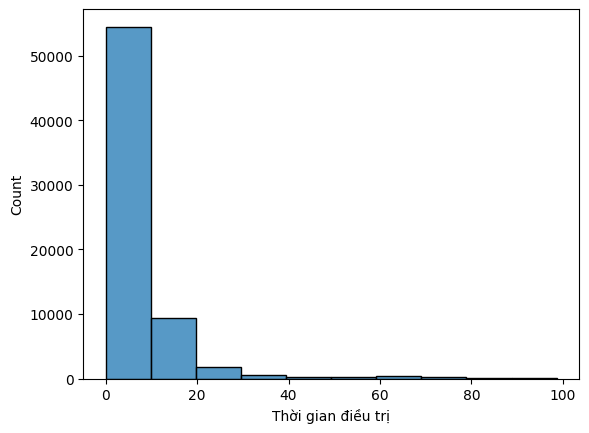

In [ ]:
sns.histplot(data = model_df[model_df['Thời gian điều trị'] <= 100], x = 'Thời gian điều trị', bins = 10)

<Axes: xlabel='Kinh độ', ylabel='Vĩ độ'>

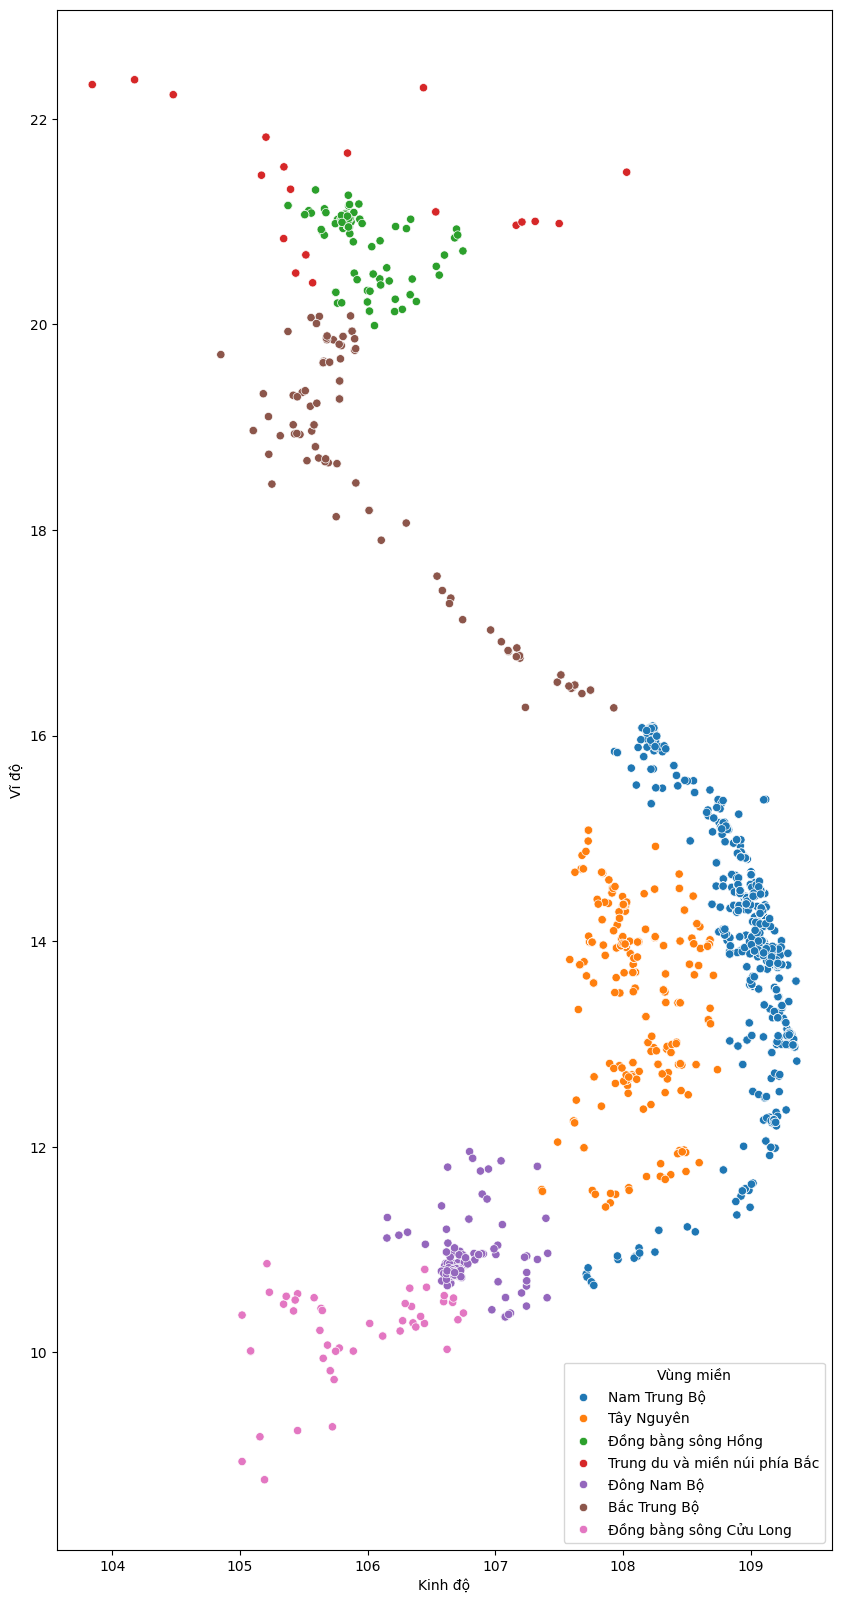

In [ ]:
plt.figure(figsize = (10,20))
sns.scatterplot(data = model_df, x = 'Kinh độ', y = 'Vĩ độ', hue = 'Vùng miền')

In [ ]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import math
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error

In [ ]:
def training():
  df = model_df.copy()
  #df['Thời gian điều trị'] = list(map(lambda x: 'Ngắn' if (x <= 7) else 'Dài',df['Thời gian điều trị']))
  #df = df.iloc[:, :-22]
  df = df.drop(columns = ['DANTOC','TONGCP','Vùng miền','Tháng nhập viện'])
  df['Thời gian điều trị'] = list(map(lambda x: math.ceil(x),df['Thời gian điều trị']))
  df = df[df['Thời gian điều trị'] <= 60]
  X = df.drop(columns = ['Thời gian điều trị'])
  y = df['Thời gian điều trị']
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
  scaler = StandardScaler()
  X_train = scaler.fit_transform(X_train)
  X_test = scaler.transform(X_test)
  model = LinearRegression()
  model.fit(X_train, y_train)
  print(model.score(X_test, y_test))
  print(mean_squared_error(y_test, model.predict(X_test)))
  #model = LogisticRegression()
  # model = RandomForestClassifier(random_state = 42)
  # model.fit(X_train, y_train)
  # print(classification_report(y_test, model.predict(X_test)))
  # print(confusion_matrix(y_test, model.predict(X_test)))
  # sns.boxplot(data = df[df['Thời gian điều trị'] <= 300], x = 'Thời gian điều trị')
  # plt.show()
  return df
training()

0.16897835989918775
43.710295504891896


,Tuổi,Thời gian điều trị,Kinh độ,Vĩ độ,Số lượng bệnh/hỗ trợ y tế,Số lượng danh mục bệnh I,Số lượng danh mục bệnh II,Số lượng danh mục bệnh III,Số lượng danh mục bệnh IV,Số lượng danh mục bệnh V,...,Số lượng danh mục bệnh XIII,Số lượng danh mục bệnh XIV,Số lượng danh mục bệnh XV,Số lượng danh mục bệnh XVI,Số lượng danh mục bệnh XVII,Số lượng danh mục bệnh XVIII,Số lượng danh mục bệnh XIX,Số lượng danh mục bệnh XX,Số lượng danh mục bệnh XXI,Số lượng danh mục bệnh XXII
0,28,1,109.191606,13.793053,1,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
1,18,1,109.181311,13.794558,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,36,1,109.068601,13.878986,2,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
3,5,3,109.148271,13.786352,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,7,109.181311,13.794558,2,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68757,73,31,109.148271,13.786352,2,0,0,1,0,0,...,0,0,0,0,0,0,0,0,1,0
68758,24,43,109.101382,13.887191,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
68759,42,43,109.030093,13.906113,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
68760,40,52,109.148393,14.220117,2,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


In [ ]:



model_df['Thời gian điều trị'] = list(map(lambda x: 'Ngắn' if (x <= 10) else 'Dài',model_df['Thời gian điều trị']))
X = model_df.drop(columns = ['Thời gian điều trị','TONGCP'])
X = pd.get_dummies(X)
y = model_df['Thời gian điều trị']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
print(y_train.value_counts())


Thời gian điều trị
Ngắn    43856
Dài     10433
Name: count, dtype: int64


In [ ]:
model_df

,Tuổi,DANTOC,Tháng nhập viện,TONGCP,Thời gian điều trị,Vùng miền,Kinh độ,Vĩ độ,Số lượng bệnh/hỗ trợ y tế,Số lượng danh mục bệnh I,...,Số lượng danh mục bệnh XIII,Số lượng danh mục bệnh XIV,Số lượng danh mục bệnh XV,Số lượng danh mục bệnh XVI,Số lượng danh mục bệnh XVII,Số lượng danh mục bệnh XVIII,Số lượng danh mục bệnh XIX,Số lượng danh mục bệnh XX,Số lượng danh mục bệnh XXI,Số lượng danh mục bệnh XXII
0,28,Kinh,1,1.500000e+04,Ngắn,Nam Trung Bộ,109.191606,13.793053,1,0,...,0,0,0,0,0,0,1,0,0,0
1,18,Kinh,1,8.334650e+04,Ngắn,Nam Trung Bộ,109.181311,13.794558,1,0,...,0,0,0,0,0,0,0,0,0,0
2,36,Kinh,1,1.599990e+02,Ngắn,Nam Trung Bộ,109.068601,13.878986,2,0,...,0,0,0,1,0,0,0,0,0,0
3,5,Kinh,12,1.129380e+05,Ngắn,Nam Trung Bộ,109.148271,13.786352,1,1,...,0,0,0,0,0,0,0,0,0,0
4,5,Kinh,12,2.623950e+05,Ngắn,Nam Trung Bộ,109.181311,13.794558,2,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68757,73,Kinh,12,1.102239e+07,Dài,Nam Trung Bộ,109.148271,13.786352,2,0,...,0,0,0,0,0,0,0,0,1,0
68758,24,Dân tộc thiểu số,11,1.359227e+07,Dài,Nam Trung Bộ,109.101382,13.887191,1,0,...,0,0,0,0,0,0,0,0,1,0
68759,42,Kinh,11,1.021012e+07,Dài,Nam Trung Bộ,109.030093,13.906113,1,0,...,0,0,0,0,0,0,0,0,1,0
68760,40,Kinh,11,1.734061e+07,Dài,Nam Trung Bộ,109.148393,14.220117,2,0,...,0,0,0,0,0,0,0,0,1,0


In [ ]:
# sm = SMOTE(sampling_strategy = {'Trung bình': 20000, 'Dài': 4000}, random_state = 42)
# X_train, y_train = sm.fit_resample(X_train, y_train)
model = RandomForestClassifier(n_estimators = 300, bootstrap = False, max_depth = 10, min_samples_split = 1000, random_state = 42)
model.fit(X_train, y_train)

RandomForestClassifier(bootstrap=False, max_depth=10, min_samples_split=1000,
                       n_estimators=300, random_state=42)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, model.predict(X_test)))
print(confusion_matrix(y_test, model.predict(X_test)))

              precision    recall  f1-score   support

         Dài       0.75      0.13      0.22      2644
        Ngắn       0.82      0.99      0.90     10929

    accuracy                           0.82     13573
   macro avg       0.79      0.56      0.56     13573
weighted avg       0.81      0.82      0.77     13573

[[  338  2306]
 [  113 10816]]


In [ ]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE


model_df['Thời gian điều trị'] = list(map(lambda x: 'Ngắn' if (x <= 10) else
                                                    'Trung bình' if (x <= 60) else 'Dài',model_df['Thời gian điều trị']))
X = model_df.drop(columns = ['Thời gian điều trị','TONGCP'])
X = pd.get_dummies(X)
y = model_df['Thời gian điều trị']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
print(y_train.value_counts())
sm = SMOTE(sampling_strategy = {'Trung bình': 20000, 'Dài': 4000}, random_state = 42)
X_train, y_train = sm.fit_resample(X_train, y_train)
model = RandomForestClassifier(n_estimators = 300, bootstrap = False, max_depth = 15, min_samples_split = 100, random_state = 42)
model.fit(X_train, y_train)

Thời gian điều trị
Ngắn          43856
Trung bình     9692
Dài             741
Name: count, dtype: int64


RandomForestClassifier(bootstrap=False, max_depth=15, min_samples_split=100,
                       n_estimators=300, random_state=42)

In [ ]:
def threshold():
  prob_df = pd.DataFrame(model.predict_proba(X_test), columns = ['Dài','Ngắn','Trung bình'])
  prob_df['Prediction'] = list(map(lambda x,y,z: 'Dài' if (x == max(x,y,z)) else
                                                 'Ngắn' if (y > z and y - z > 0.15) else
                                                 'Trung bình',prob_df['Dài'],prob_df['Ngắn'],prob_df['Trung bình']))
  prob_df['Actual'] = y_test.reset_index(drop = True)
  print(classification_report(prob_df['Actual'], prob_df['Prediction']))
  print(confusion_matrix(prob_df['Actual'], prob_df['Prediction']))

threshold()


              precision    recall  f1-score   support

         Dài       0.56      0.78      0.65       175
        Ngắn       0.88      0.83      0.86     10929
  Trung bình       0.40      0.48      0.43      2469

    accuracy                           0.77     13573
   macro avg       0.61      0.70      0.65     13573
weighted avg       0.79      0.77      0.78     13573

[[ 137    8   30]
 [  60 9106 1763]
 [  49 1243 1177]]


In [ ]:
def importance():
  feature_importances = model.feature_importances_
  feature_names = X.columns
  feature_importance_df = pd.DataFrame({
      'Feature': feature_names,
      'Importance': feature_importances
  })
  feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
  print(feature_importance_df)

importance()

                                    Feature  Importance
25               Số lượng danh mục bệnh XXI    0.317982
0                                      Tuổi    0.171586
19                Số lượng danh mục bệnh XV    0.062457
3                                     Vĩ độ    0.061536
4                 Số lượng bệnh/hỗ trợ y tế    0.058180
2                                   Kinh độ    0.057972
1                           Tháng nhập viện    0.044761
5                  Số lượng danh mục bệnh I    0.033937
6                 Số lượng danh mục bệnh II    0.032736
13                Số lượng danh mục bệnh IX    0.023378
15                Số lượng danh mục bệnh XI    0.021797
22             Số lượng danh mục bệnh XVIII    0.015048
17              Số lượng danh mục bệnh XIII    0.014138
23               Số lượng danh mục bệnh XIX    0.013028
12              Số lượng danh mục bệnh VIII    0.010655
11               Số lượng danh mục bệnh VII    0.009645
14                 Số lượng danh mục bệnh X    0